In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

# Data klaar zetten

In [2]:
df_laadpark = pd.read_csv('data/ev_consumption.csv', parse_dates=['Date'])
df_2024 = pd.read_excel('data/energie_orac_2024.xlsx', parse_dates=['datetime'])
df_2025 = pd.read_excel('data/energie_orac_2025.xlsx', parse_dates=['datetime'])
df_2026 = pd.read_excel('data/energie_orac_2026.xlsx', parse_dates=['datetime'])
df_laadsessies = pd.read_excel('data/Sessions (1) (1).xlsx', parse_dates=['From', 'To'])

In [3]:
#resample df_2024, df_2025, df_2026 to 1h 
df_2024.set_index('datetime', inplace=True)
df_2024 = df_2024.resample('1h').sum()
df_2025.set_index('datetime', inplace=True)
df_2025 = df_2025.resample('1h').sum()
df_2026.set_index('datetime', inplace=True)
df_2026 = df_2026.resample('1h').sum()

In [4]:
df_2025.head()

,afname_kwh,injectie_kwh,productie_kwh
datetime,,,
2025-01-01 00:00:00,43.125,0.0,0.0
2025-01-01 01:00:00,47.500,0.0,0.0
2025-01-01 02:00:00,53.125,0.0,0.0
2025-01-01 03:00:00,50.000,0.0,0.0
2025-01-01 04:00:00,65.625,0.0,0.0


In [5]:
df_2025["totaal_verbruik_kwh"] = df_2025["afname_kwh"] + df_2025["productie_kwh"] - df_2025["injectie_kwh"]
df_2025.head()

,afname_kwh,injectie_kwh,productie_kwh,totaal_verbruik_kwh
datetime,,,,
2025-01-01 00:00:00,43.125,0.0,0.0,43.125
2025-01-01 01:00:00,47.500,0.0,0.0,47.500
2025-01-01 02:00:00,53.125,0.0,0.0,53.125
2025-01-01 03:00:00,50.000,0.0,0.0,50.000
2025-01-01 04:00:00,65.625,0.0,0.0,65.625


In [6]:
df_2026["totaal_verbruik_kwh"] = df_2026["afname_kwh"] + df_2026["productie_kwh"] - df_2026["injectie_kwh"]
df_2026.head()

,afname_kwh,injectie_kwh,productie_kwh,totaal_verbruik_kwh
datetime,,,,
2026-01-01 00:00:00,40.000,0.0,0.0875,40.0875
2026-01-01 01:00:00,40.000,0.0,0.1000,40.1000
2026-01-01 02:00:00,40.625,0.0,0.0875,40.7125
2026-01-01 03:00:00,42.500,0.0,0.1000,42.6000
2026-01-01 04:00:00,49.375,0.0,0.0875,49.4625


In [7]:
df_2024["totaal_verbruik_kwh"] = df_2024["afname_kwh"] + df_2024["productie_kwh"] - df_2024["injectie_kwh"]
df_2024.head()

,afname_kwh,injectie_kwh,productie_kwh,totaal_verbruik_kwh
datetime,,,,
2024-01-01 00:00:00,46.875,0.0,0.0,46.875
2024-01-01 01:00:00,54.375,0.0,0.0,54.375
2024-01-01 02:00:00,51.875,0.0,0.0,51.875
2024-01-01 03:00:00,53.125,0.0,0.0,53.125
2024-01-01 04:00:00,71.875,0.0,0.0,71.875


In [8]:
df_laadpark.head()

,Date,total_consumption_ev
0,2025-05-06 00:00:00,0.005
1,2025-05-06 01:00:00,0.006
2,2025-05-06 02:00:00,0.006
3,2025-05-06 03:00:00,0.006
4,2025-05-06 04:00:00,0.006


In [9]:
#min & max datum van df_laadpark
min_date = df_laadpark['Date'].min()
max_date = df_laadpark['Date'].max()

In [10]:
print(f"Min date in df_laadpark: {min_date}")
print(f"Max date in df_laadpark: {max_date}")

Min date in df_laadpark: 2025-05-06 00:00:00
Max date in df_laadpark: 2026-05-01 23:00:00


In [11]:
df_2024.head()

,afname_kwh,injectie_kwh,productie_kwh,totaal_verbruik_kwh
datetime,,,,
2024-01-01 00:00:00,46.875,0.0,0.0,46.875
2024-01-01 01:00:00,54.375,0.0,0.0,54.375
2024-01-01 02:00:00,51.875,0.0,0.0,51.875
2024-01-01 03:00:00,53.125,0.0,0.0,53.125
2024-01-01 04:00:00,71.875,0.0,0.0,71.875


In [12]:
#df_2025 & df_2026 samenvoegen in 1 dataframe
df_2025_2026 = pd.concat([df_2025, df_2026])
df_2025_2026.head()

,afname_kwh,injectie_kwh,productie_kwh,totaal_verbruik_kwh
datetime,,,,
2025-01-01 00:00:00,43.125,0.0,0.0,43.125
2025-01-01 01:00:00,47.500,0.0,0.0,47.500
2025-01-01 02:00:00,53.125,0.0,0.0,53.125
2025-01-01 03:00:00,50.000,0.0,0.0,50.000
2025-01-01 04:00:00,65.625,0.0,0.0,65.625


In [13]:
#min & max datum van df_2025_2026
min_date_2025_2026 = df_2025_2026.index.min()
max_date_2025_2026 = df_2025_2026.index.max()

print(f"Min date in df_2025_2026: {min_date_2025_2026}")
print(f"Max date in df_2025_2026: {max_date_2025_2026}")

Min date in df_2025_2026: 2025-01-01 00:00:00
Max date in df_2025_2026: 2026-04-30 23:00:00


In [14]:
#filter zodat ik enkel Min date in df_laadpark: 2025-05-06 00:00:00 Max date in df_laadpark: 2026-05-01 23:00:00
df_2025_2026_filtered = df_2025_2026[(df_2025_2026.index >= min_date) & (df_2025_2026.index <= max_date)]
df_2025_2026_filtered.head()

,afname_kwh,injectie_kwh,productie_kwh,totaal_verbruik_kwh
datetime,,,,
2025-05-06 00:00:00,355.000,0.0,0.0,355.000
2025-05-06 01:00:00,334.375,0.0,0.0,334.375
2025-05-06 02:00:00,364.375,0.0,0.0,364.375
2025-05-06 03:00:00,383.750,0.0,0.0,383.750
2025-05-06 04:00:00,356.875,0.0,0.0,356.875


In [15]:
#df_laadpark kolom naam 'date' naar 'datetime' veranderen
df_laadpark.rename(columns={'Date': 'datetime'}, inplace=True)
df_laadpark.head()

,datetime,total_consumption_ev
0,2025-05-06 00:00:00,0.005
1,2025-05-06 01:00:00,0.006
2,2025-05-06 02:00:00,0.006
3,2025-05-06 03:00:00,0.006
4,2025-05-06 04:00:00,0.006


In [16]:
#index van datetime in df_laadpark zetten
df_laadpark.set_index('datetime', inplace=True)
df_laadpark.head()

,total_consumption_ev
datetime,
2025-05-06 00:00:00,0.005
2025-05-06 01:00:00,0.006
2025-05-06 02:00:00,0.006
2025-05-06 03:00:00,0.006
2025-05-06 04:00:00,0.006


In [17]:
#voeg df_laadpark toe aan df_2025_2026_filtered op basis van de datum
df_main = df_2025_2026_filtered.merge(df_laadpark, left_index=True, right_index=True, how='left')
df_main.head()

,afname_kwh,injectie_kwh,productie_kwh,totaal_verbruik_kwh,total_consumption_ev
datetime,,,,,
2025-05-06 00:00:00,355.000,0.0,0.0,355.000,0.005
2025-05-06 01:00:00,334.375,0.0,0.0,334.375,0.006
2025-05-06 02:00:00,364.375,0.0,0.0,364.375,0.006
2025-05-06 03:00:00,383.750,0.0,0.0,383.750,0.006
2025-05-06 04:00:00,356.875,0.0,0.0,356.875,0.006


In [18]:
df_main["verbruik_gebouw_kwh"] = df_main["totaal_verbruik_kwh"] - df_main["total_consumption_ev"]
df_main.head()

,afname_kwh,injectie_kwh,productie_kwh,totaal_verbruik_kwh,total_consumption_ev,verbruik_gebouw_kwh
datetime,,,,,,
2025-05-06 00:00:00,355.000,0.0,0.0,355.000,0.005,354.995
2025-05-06 01:00:00,334.375,0.0,0.0,334.375,0.006,334.369
2025-05-06 02:00:00,364.375,0.0,0.0,364.375,0.006,364.369
2025-05-06 03:00:00,383.750,0.0,0.0,383.750,0.006,383.744
2025-05-06 04:00:00,356.875,0.0,0.0,356.875,0.006,356.869


In [19]:
print(f"Som totaal verbruik: {df_main['totaal_verbruik_kwh'].sum()/1000:.2f} MWh")

Som totaal verbruik: 2344.84 MWh


In [20]:
print(f"Som totaal verbruik EV: {df_main['total_consumption_ev'].sum()/1000:.2f} MWh")

Som totaal verbruik EV: 106.47 MWh


In [21]:
#% verbruik EV ten opzichte van totaal verbruik
percentage_ev = (df_main['total_consumption_ev'].sum() / df_main['totaal_verbruik_kwh'].sum()) * 100
print(f"Percentage verbruik EV ten opzichte van totaal verbruik: {percentage_ev:.2f}%")

Percentage verbruik EV ten opzichte van totaal verbruik: 4.54%


In [22]:
#verwijder in df_main afname_kwh, productie_kwh, injectie_kwh
df_main.drop(columns=['afname_kwh', 'productie_kwh', 'injectie_kwh'], inplace=True)
df_main.head()

,totaal_verbruik_kwh,total_consumption_ev,verbruik_gebouw_kwh
datetime,,,
2025-05-06 00:00:00,355.000,0.005,354.995
2025-05-06 01:00:00,334.375,0.006,334.369
2025-05-06 02:00:00,364.375,0.006,364.369
2025-05-06 03:00:00,383.750,0.006,383.744
2025-05-06 04:00:00,356.875,0.006,356.869


In [23]:
# kopieën
df_main = df_main.copy()
df_2024 = df_2024.copy()

# maak sleutel zonder jaar
df_main["mdh"] = df_main.index.strftime("%m-%d %H")
df_2024["mdh"] = df_2024.index.strftime("%m-%d %H")

# mapping maken uit 2024
prod_map = df_2024.groupby("mdh")["productie_kwh"].mean()

# toepassen op main
df_main["productie_kwh"] = df_main["mdh"].map(prod_map)

# cleanup
df_main = df_main.drop(columns=["mdh"])

In [24]:
df_main.head()

,totaal_verbruik_kwh,total_consumption_ev,verbruik_gebouw_kwh,productie_kwh
datetime,,,,
2025-05-06 00:00:00,355.000,0.005,354.995,0.0
2025-05-06 01:00:00,334.375,0.006,334.369,0.0
2025-05-06 02:00:00,364.375,0.006,364.369,0.0
2025-05-06 03:00:00,383.750,0.006,383.744,0.0
2025-05-06 04:00:00,356.875,0.006,356.869,0.0


In [25]:
#zet productie_kwh als eerste kolom (na datetime)
cols = df_main.columns.tolist()
cols.insert(0, cols.pop(cols.index('productie_kwh')))
df_main = df_main[cols]
df_main.head()

,productie_kwh,totaal_verbruik_kwh,total_consumption_ev,verbruik_gebouw_kwh
datetime,,,,
2025-05-06 00:00:00,0.0,355.000,0.005,354.995
2025-05-06 01:00:00,0.0,334.375,0.006,334.369
2025-05-06 02:00:00,0.0,364.375,0.006,364.369
2025-05-06 03:00:00,0.0,383.750,0.006,383.744
2025-05-06 04:00:00,0.0,356.875,0.006,356.869


In [26]:
#nu bereken injectie & afname e.	If totaal verbruik > productie = afname / totaalverbruik < productie = injectie
df_main["injectie_kwh"] = np.where(df_main["totaal_verbruik_kwh"] < df_main["productie_kwh"], df_main["productie_kwh"] - df_main["totaal_verbruik_kwh"], 0)
df_main["afname_kwh"] = np.where(df_main["totaal_verbruik_kwh"] > df_main["productie_kwh"], df_main["totaal_verbruik_kwh"] - df_main["productie_kwh"], 0)
df_main.head()

,productie_kwh,totaal_verbruik_kwh,total_consumption_ev,verbruik_gebouw_kwh,injectie_kwh,afname_kwh
datetime,,,,,,
2025-05-06 00:00:00,0.0,355.000,0.005,354.995,0.0,355.000
2025-05-06 01:00:00,0.0,334.375,0.006,334.369,0.0,334.375
2025-05-06 02:00:00,0.0,364.375,0.006,364.369,0.0,364.375
2025-05-06 03:00:00,0.0,383.750,0.006,383.744,0.0,383.750
2025-05-06 04:00:00,0.0,356.875,0.006,356.869,0.0,356.875


In [27]:
#zet afname & inectie naast elkaar voor productie
cols = df_main.columns.tolist()
cols.insert(1, cols.pop(cols.index('afname_kwh')))
cols.insert(2, cols.pop(cols.index('injectie_kwh')))
df_main = df_main[cols]
df_main.head(50)

,productie_kwh,afname_kwh,injectie_kwh,totaal_verbruik_kwh,total_consumption_ev,verbruik_gebouw_kwh
datetime,,,,,,
2025-05-06 00:00:00,0.000000,355.000000,0.000000,355.000000,0.005,354.995000
2025-05-06 01:00:00,0.000000,334.375000,0.000000,334.375000,0.006,334.369000
2025-05-06 02:00:00,0.000000,364.375000,0.000000,364.375000,0.006,364.369000
2025-05-06 03:00:00,0.000000,383.750000,0.000000,383.750000,0.006,383.744000
2025-05-06 04:00:00,0.000000,356.875000,0.000000,356.875000,0.006,356.869000
2025-05-06 05:00:00,0.000000,365.000000,0.000000,365.000000,0.006,364.994000
2025-05-06 06:00:00,1.461686,384.511325,0.000000,385.973011,0.006,385.967011
2025-05-06 07:00:00,7.962013,355.084009,0.000000,363.046022,3.147,359.899022
2025-05-06 08:00:00,22.317146,431.193545,0.000000,453.510691,55.231,398.279691


In [28]:
#alle waarden afronden op 2 decimalen
df_main = df_main.round(2)

In [29]:
df_main.head()

,productie_kwh,afname_kwh,injectie_kwh,totaal_verbruik_kwh,total_consumption_ev,verbruik_gebouw_kwh
datetime,,,,,,
2025-05-06 00:00:00,0.0,355.00,0.0,355.00,0.00,355.00
2025-05-06 01:00:00,0.0,334.38,0.0,334.38,0.01,334.37
2025-05-06 02:00:00,0.0,364.38,0.0,364.38,0.01,364.37
2025-05-06 03:00:00,0.0,383.75,0.0,383.75,0.01,383.74
2025-05-06 04:00:00,0.0,356.88,0.0,356.88,0.01,356.87


In [30]:
#som van afname_kwh, productie_kwh, injectie_kwh, totaal_verbruik_kwh, total_consumption_ev, verbruik_gebouw_kwh
total_afname = df_main['afname_kwh'].sum()
total_productie = df_main['productie_kwh'].sum()
total_injectie = df_main['injectie_kwh'].sum()
total_verbruik = df_main['totaal_verbruik_kwh'].sum()
total_consumption_ev = df_main['total_consumption_ev'].sum()
total_verbruik_gebouw = df_main['verbruik_gebouw_kwh'].sum()

print(f"Total afname_kwh: {total_afname/1000:.2f} MWh")
print(f"Total productie_kwh: {total_productie/1000:.2f} MWh")
print(f"Total injectie_kwh: {total_injectie/1000:.2f} MWh")
print(f"Total totaal_verbruik_kwh: {total_verbruik/1000:.2f} MWh")
print(f"Total total_consumption_ev: {total_consumption_ev/1000:.2f} MWh")
print(f"Total verbruik_gebouw_kwh: {total_verbruik_gebouw/1000:.2f} MWh")


Total afname_kwh: 1740.49 MWh
Total productie_kwh: 1200.79 MWh
Total injectie_kwh: 596.44 MWh
Total totaal_verbruik_kwh: 2344.84 MWh
Total total_consumption_ev: 106.47 MWh
Total verbruik_gebouw_kwh: 2237.52 MWh


In [31]:
#verander total_consumption_ev naar verbruik_ev_kwh
df_main.rename(columns={'total_consumption_ev': 'verbruik_ev_kwh'}, inplace=True)
df_main.head()

,productie_kwh,afname_kwh,injectie_kwh,totaal_verbruik_kwh,verbruik_ev_kwh,verbruik_gebouw_kwh
datetime,,,,,,
2025-05-06 00:00:00,0.0,355.00,0.0,355.00,0.00,355.00
2025-05-06 01:00:00,0.0,334.38,0.0,334.38,0.01,334.37
2025-05-06 02:00:00,0.0,364.38,0.0,364.38,0.01,364.37
2025-05-06 03:00:00,0.0,383.75,0.0,383.75,0.01,383.74
2025-05-06 04:00:00,0.0,356.88,0.0,356.88,0.01,356.87


In [32]:
#maak excel bestand aan met df_main
df_main.to_excel('data/profiel_orac.xlsx', index=True)

In [33]:
#maak excel bestand aan met df_main
df_main.to_csv('data/profiel_orac.csv', index=True)

In [34]:
#kijk voor dubbele datums in df_main
duplicate_dates = df_main.index[df_main.index.duplicated()]
if not duplicate_dates.empty:
    print("Dubbele datums gevonden:")
    print(duplicate_dates)

#verwijder dubbele datums
df_main = df_main[~df_main.index.duplicated(keep='first')]


Dubbele datums gevonden:
DatetimeIndex(['2025-10-26 01:00:00'], dtype='datetime64[ns]', name='datetime', freq=None)


In [35]:
duplicate_dates = df_main.index[df_main.index.duplicated()]
if not duplicate_dates.empty:
    print("Dubbele datums gevonden:")
    print(duplicate_dates)

# Laadstrategiën

In [36]:
df_laadsessies.head()

,Charging station name,From,To,Duration [h:mm],kWh,Activation method,Cost,Net price,CPO fee,Connector,Token
0,Ev Base Orac 1,2025-05-02 08:04:42,2025-05-02 12:50:06,04:45,5.844,Whitelisting,NaN,NaN,NaN,1,16D2CFF0 (Thibault Lingier badge)
1,Ev Base Orac 3,2025-05-02 08:59:36,2025-05-02 12:02:22,03:03,8.811,Whitelisting,NaN,NaN,NaN,1,0468D9FD (Martijn Meert - badge)
2,Ev Base Orac 9,2025-05-05 06:49:06,2025-05-05 15:34:22,08:45,37.098,Scan and charge,12.27,8.904,0.886,1,NaN
3,Ev Base Orac 2,2025-05-05 07:29:48,2025-05-05 17:14:58,09:45,34.934,Swipe and charge,NaN,13.970,1.400,2,NaN
4,Ev Base Orac 1,2025-05-05 07:55:30,2025-05-05 16:11:33,08:16,52.922,Whitelisting,NaN,NaN,NaN,2,62830CD2 (Ivan Kotov badge)


In [37]:
# ============================================================
# DATA PREPARATION LAADSESSIES
# ============================================================

# 1. Zet kolommen om naar datetimes
df_laadsessies['From'] = pd.to_datetime(df_laadsessies['From'])
df_laadsessies['To'] = pd.to_datetime(df_laadsessies['To'])

# 2. Bereken de exacte connectieduur in decimale uren
df_laadsessies['Duration_hours'] = (df_laadsessies['To'] - df_laadsessies['From']).dt.total_seconds() / 3600

# 3. FILTEREN:
initial_rows = len(df_laadsessies)

# Schoonmaak A: Verwijder sessies zonder noemenswaardige energie of tijd
df_laadsessies = df_laadsessies[df_laadsessies['kWh'] > 0.2]
df_laadsessies = df_laadsessies[df_laadsessies['Duration_hours'] > 0.08] # langer dan 5 min

# Schoonmaak B: Fysische check (gemiddeld laadvermogen mag NOOIT > 11 kW zijn)
df_laadsessies = df_laadsessies[(df_laadsessies['kWh'] / df_laadsessies['Duration_hours']) <= 11.1]

# Schoonmaak C: Verwijder 'langstayers' (bijv. auto's die langer dan 24u blijven staan)
# In een kantoorsimulatie zijn sessies > 24u vaak data-fouten of auto's die overbezet staan.
df_laadsessies = df_laadsessies[df_laadsessies['Duration_hours'] <= 24.0]

print(f"Schoonmaak voltooid: {initial_rows - len(df_laadsessies)} foutieve of irrelevante sessies verwijderd.")
print(f"Aantal bruikbare laadsessies over: {len(df_laadsessies)}")

# 4. RELEVANTE KOLOMMEN BEWAREN
# Kolommen zoals Cost, Token, Activation method hebben we niet nodig voor de simulatie.
kolommen_voor_simulatie = ['Charging station name', 'From', 'To', 'Duration_hours', 'kWh']
df_laad_clean = df_laadsessies[kolommen_voor_simulatie].copy()

display(df_laad_clean.head())

Schoonmaak voltooid: 251 foutieve of irrelevante sessies verwijderd.
Aantal bruikbare laadsessies over: 3357


,Charging station name,From,To,Duration_hours,kWh
0,Ev Base Orac 1,2025-05-02 08:04:42,2025-05-02 12:50:06,4.756667,5.844
1,Ev Base Orac 3,2025-05-02 08:59:36,2025-05-02 12:02:22,3.046111,8.811
2,Ev Base Orac 9,2025-05-05 06:49:06,2025-05-05 15:34:22,8.754444,37.098
3,Ev Base Orac 2,2025-05-05 07:29:48,2025-05-05 17:14:58,9.752778,34.934
4,Ev Base Orac 1,2025-05-05 07:55:30,2025-05-05 16:11:33,8.267500,52.922


In [38]:
import pandas as pd
import numpy as np

def strategie_1_ongecoordineerd_micro(df_hoofd, df_sessies, n_laadpunten=20, p_max_punt=11.0, tijdstap_h=1.0):
    """
    Simuleert de Ongecoördineerde (S1) strategie op MICRO-niveau.
    Houdt rekening met max 11 kW per auto én max 220 kW voor het hele plein.
    """
    # Bereken de absolute fysieke limiet van het laadplein (bijv. 220 kW)
    p_max_totaal = n_laadpunten * p_max_punt 

    # Maak een werkkopie van de sessies en voeg een teller toe per auto
    sessions = df_sessies.copy()
    sessions['kWh_geladen_teller'] = 0.0 

    # Maak een lege Series aan voor het resultaat
    P_laad_reeks = pd.Series(0.0, index=df_hoofd.index)

    print(f"Micro-simulatie S1 wordt uitgevoerd ({n_laadpunten} laadpunten van {p_max_punt} kW)...")

    # Loop uur voor uur door de tijdlijn van het gebouw
    for t in df_hoofd.index:
        t_volgend = t + pd.Timedelta(hours=tijdstap_h)
        
        # Welke auto's zijn aanwezig tijdens dit specifieke uur?
        mask_aanwezig = (sessions['From'] < t_volgend) & (sessions['To'] > t)
        actieve_autos = sessions[mask_aanwezig]
        
        # Tijdelijke dictionary om de laadvraag van dit uur per auto op te slaan
        p_per_auto = {}
        totaal_gevraagd_dit_uur = 0.0
        
        # Stap A: Bereken wat elke auto *zou willen* laden (max 11 kW of minder als hij bijna vol is)
        for idx, row in actieve_autos.iterrows():
            energie_tekort = max(0.0, row['kWh'] - row['kWh_geladen_teller'])
            if energie_tekort > 0:
                p_auto = min(p_max_punt, energie_tekort / tijdstap_h)
                p_per_auto[idx] = p_auto
                totaal_gevraagd_dit_uur += p_auto
        
        # Stap B: Infrastructuur-beveiliging (max 220 kW)
        # Als er door data-overlap meer dan 220 kW wordt gevraagd, schalen we iedereen evenredig terug
        scaling_factor = 1.0
        if totaal_gevraagd_dit_uur > p_max_totaal:
            scaling_factor = p_max_totaal / totaal_gevraagd_dit_uur
            
        # Stap C: De tellers updaten met het werkelijk toegekende vermogen
        totaal_effectief_dit_uur = 0.0
        for idx, p_auto in p_per_auto.items():
            p_toegekend = p_auto * scaling_factor
            sessions.loc[idx, 'kWh_geladen_teller'] += p_toegekend * tijdstap_h
            totaal_effectief_dit_uur += p_toegekend
            
        # Sla het totale EV-laadvermogen van dit uur op
        P_laad_reeks[t] = totaal_effectief_dit_uur

    return P_laad_reeks.rename('P_laad_S1')

# ============================================================
# AANROEPEN MET JOUW SPECIFIEKE PARAMETERS
# ============================================================
N_LAADPUNTEN = 20
P_MAX_PUNT_KW = 11

df_main['P_laad_S1'] = strategie_1_ongecoordineerd_micro(
    df_hoofd=df_main, 
    df_sessies=df_laad_clean, 
    n_laadpunten=N_LAADPUNTEN, 
    p_max_punt=P_MAX_PUNT_KW, 
    tijdstap_h=1.0
)

df_main['P_net_S1'] = (
    df_main['verbruik_gebouw_kwh'] 
    + df_main['P_laad_S1'] 
    - df_main['productie_kwh']
)

Micro-simulatie S1 wordt uitgevoerd (20 laadpunten van 11 kW)...


In [39]:
import pandas as pd
import numpy as np

def strategie_2_smart_zc_micro(df_hoofd, df_sessies, n_laadpunten=20, p_max_punt=11.0, tijdstap_h=1.0):
    """
    Simuleert de Smart Zelfconsumptie (S2) strategie op MICRO-niveau.
    Auto's laden primair op zonne-overschot, tenzij ze in tijdnood komen om hun kWh-doel te halen.
    """
    p_max_totaal = n_laadpunten * p_max_punt
    sessions = df_sessies.copy()
    sessions['kWh_geladen_teller'] = 0.0  # Houdt per auto de voortgang bij

    P_laad_reeks = pd.Series(0.0, index=df_hoofd.index)

    print(f"Micro-simulatie S2 (Smart ZC) wordt uitgevoerd met {n_laadpunten} laadpunten...")

    # Loop uur voor uur door de tijdlijn van het gebouw
    for t in df_hoofd.index:
        t_volgend = t + pd.Timedelta(hours=tijdstap_h)
        
        # 1. Bereken het actuele zonne-overschot (gratis stroom) in dit specifieke uur
        pv_overschot = max(0.0, df_hoofd.loc[t, 'productie_kwh'] - df_hoofd.loc[t, 'verbruik_gebouw_kwh'])
        
        # 2. Welke auto's zijn er tijdens dit uur aanwezig?
        mask_aanwezig = (sessions['From'] < t_volgend) & (sessions['To'] > t)
        actieve_autos = sessions[mask_aanwezig]
        
        if len(actieve_autos) == 0:
            continue
            
        autos_in_tijdnood = []
        autos_wachtend = []
        p_toegekend = {}
        totaal_p_dit_uur = 0.0
        
        # 3. RONDE 1: Controleer de status van elke aanwezige auto (De virtuele SOC check)
        for idx, row in actieve_autos.iterrows():
            tekort = max(0.0, row['kWh'] - row['kWh_geladen_teller'])
            if tekort <= 0:
                continue  # Deze auto is al volledig volgeladen!
                
            # Hoeveel uur heeft deze auto nog vanaf NU (t) tot zijn harde deadline (To)?
            uren_tot_vertrek = (row['To'] - t).total_seconds() / 3600
            
            # Wat kan deze auto maximaal nog fysiek opnemen tot hij wegrijdt?
            max_kwh_tot_vertrek = uren_tot_vertrek * p_max_punt
            
            # Wat wil/kan hij dit specifieke uur maximaal laden?
            p_max_dit_uur = min(p_max_punt, tekort / tijdstap_h)
            
            # DE VIRTUELE SOC/DEADLINE CHECK:
            if tekort >= max_kwh_tot_vertrek:
                # RECHTSTREEKS NAAR HET NET: Als we NU niet vol aanzetten, halen we het nooit meer!
                autos_in_tijdnood.append((idx, p_max_dit_uur))
            else:
                # ZONNE-SPONS: Deze auto heeft nog tijd over en wacht bij voorkeur op de zon
                autos_wachtend.append((idx, p_max_dit_uur))
                
        # 4. RONDE 2: Verdeel de stroom
        # A. Help eerst de auto's in nood (dit forceert netafname als er geen zon is)
        for idx, p_nodig in autos_in_tijdnood:
            p_toegekend[idx] = p_nodig
            totaal_p_dit_uur += p_nodig
            
        # B. Hoeveel fysieke ruimte is er nog over op het laadpleen (max 220 kW)?
        resterende_paal_ruimte = max(0.0, p_max_totaal - totaal_p_dit_uur)
        
        # C. Hoeveel zonnestroom is er nog over voor de wachtende auto's?
        zon_beschikbaar = max(0.0, pv_overschot - totaal_p_dit_uur)
        zon_voor_ev = min(resterende_paal_ruimte, zon_beschikbaar)
        
        # D. Verdeel de overgebleven zonnestroom eerlijk onder de 'geduldige' auto's
        if len(autos_wachtend) > 0 and zon_voor_ev > 0:
            p_deel_per_auto = zon_voor_ev / len(autos_wachtend)
            for idx, p_max_dit_uur in autos_wachtend:
                p_ev_zon = min(p_max_dit_uur, p_deel_per_auto)
                p_toegekend[idx] = p_ev_zon
                totaal_p_dit_uur += p_ev_zon
                
        # 5. Infrastructuur-veiligheid: voorkom dat we door afrondingen de 220 kW overschrijden
        if totaal_p_dit_uur > p_max_totaal:
            sf = p_max_totaal / totaal_p_dit_uur
            for idx in p_toegekend:
                p_toegekend[idx] *= sf
            totaal_p_dit_uur = p_max_totaal
            
        # 6. Sla de geladen energie op in de tellers voor het volgende uur
        for idx, p_final in p_toegekend.items():
            sessions.loc[idx, 'kWh_geladen_teller'] += p_final * tijdstap_h
            
        P_laad_reeks[t] = totaal_p_dit_uur

    return P_laad_reeks.rename('P_laad_S2')

# ============================================================
# AANROEPEN IN JE NOTEBOOK
# ============================================================
df_main['P_laad_S2'] = strategie_2_smart_zc_micro(
    df_hoofd=df_main, 
    df_sessies=df_laad_clean, 
    n_laadpunten=20, 
    p_max_punt=11.0, 
    tijdstap_h=1.0
)

df_main['P_net_S2'] = (
    df_main['verbruik_gebouw_kwh'] 
    + df_main['P_laad_S2'] 
    - df_main['productie_kwh']
)

Micro-simulatie S2 (Smart ZC) wordt uitgevoerd met 20 laadpunten...


In [40]:
import pandas as pd
import numpy as np

def strategie_3_smart_zc_piek_micro(df_hoofd, df_sessies, p_net_cap, n_laadpunten=20, p_max_punt=11.0, tijdstap_h=1.0):
    """
    Simuleert de Smart ZC + Piekreductie (S3) strategie op MICRO-niveau.
    Smeert de laadvraag zo vlak mogelijk uit en remt het laden af zodra
    de totale netafname de contractlimiet (p_net_cap) dreigt te overschrijden.
    """
    p_max_totaal = n_laadpunten * p_max_punt
    sessions = df_sessies.copy()
    sessions['kWh_geladen_teller'] = 0.0  # Volg de voortgang per auto

    P_laad_reeks = pd.Series(0.0, index=df_hoofd.index)

    print(f"Micro-simulatie S3 (ZC + Piek) wordt uitgevoerd. Netlimiet = {p_net_cap} kW...")

    # Loop uur voor uur door de tijdlijn van het gebouw
    for t in df_hoofd.index:
        t_volgend = t + pd.Timedelta(hours=tijdstap_h)
        
        # 1. Analyseer de netruimte zonder EV's in dit uur
        net_zonder_ev = df_hoofd.loc[t, 'verbruik_gebouw_kwh'] - df_hoofd.loc[t, 'productie_kwh']
        pv_overschot = max(0.0, -net_zonder_ev) # Als net_zonder_ev negatief is, hebben we overschot
        
        # Hoeveel vermogen is er nog over op het net voordat we de contractpiek overschrijden?
        p_cap_ev = max(0.0, p_net_cap - net_zonder_ev)
        
        # 2. Welke auto's zijn er nu aanwezig?
        mask_aanwezig = (sessions['From'] < t_volgend) & (sessions['To'] > t)
        actieve_autos = sessions[mask_aanwezig]
        
        if len(actieve_autos) == 0:
            continue
            
        p_toegekend = {}
        totaal_min_nodig_dit_uur = 0.0
        autos_die_extra_willen = []
        
        # 3. RONDE 1: Bereken voor elke auto het 'vlakke' minimale vermogen (Smeren!)
        for idx, row in actieve_autos.iterrows():
            tekort = max(0.0, row['kWh'] - row['kWh_geladen_teller'])
            if tekort <= 0:
                continue
                
            uren_tot_vertrek = (row['To'] - t).total_seconds() / 3600
            p_max_dit_uur = min(p_max_punt, tekort / tijdstap_h)
            
            # Bereken het minimale vermogen om de auto exact op tijd vol te krijgen zonder haast
            if uren_tot_vertrek > 0:
                p_min_nodig = min(p_max_dit_uur, tekort / uren_tot_vertrek)
            else:
                p_min_nodig = p_max_dit_uur
                
            p_toegekend[idx] = p_min_nodig
            totaal_min_nodig_dit_uur += p_min_nodig
            
            # Als de auto nóg sneller zou kunnen laden op zonnestroom, onthouden we dat
            if p_max_dit_uur > p_min_nodig:
                autos_die_extra_willen.append((idx, p_max_dit_uur - p_min_nodig))
                
        # 4. RONDE 2: Extra zonnestroom verdelen (bovenop het minimum)
        # We kijken hoeveel zonnestroom er over is nadat we aan het minimum hebben voldaan
        extra_zon_beschikbaar = max(0.0, pv_overschot - totaal_min_nodig_dit_uur)
        
        # We controleren ook de fysieke ruimte op het laadpleen
        resterende_paal_ruimte = max(0.0, p_max_totaal - totaal_min_nodig_dit_uur)
        extra_ruimte_voor_zon = min(resterende_paal_ruimte, extra_zon_beschikbaar)
        
        if len(autos_die_extra_willen) > 0 and extra_ruimte_voor_zon > 0:
            deeltje_per_auto = extra_ruimte_voor_zon / len(autos_die_extra_willen)
            for idx, max_extra_mogelijk in autos_die_extra_willen:
                p_extra = min(max_extra_mogelijk, deeltje_per_auto)
                p_toegekend[idx] += p_extra
                
        # 5. PEAK SHAVING CHECK (De harde rem!)
        # We tellen het totale toegekende vermogen op
        totaal_p_gevraagd = sum(p_toegekend.values())
        
        # Als het totale laden groter is dan de netruimte (p_cap_ev)...
        if totaal_p_gevraagd > p_cap_ev:
            # S3 REGEL: We remmen af tot p_cap_ev, MAAR we mogen NOOIT lager zakken 
            # dan het absolute minimum dat nodig is om de auto's rijklaar te maken.
            p_veilig = max(totaal_min_nodig_dit_uur, p_cap_ev)
            
            # Voorkom dat we boven de fysieke limiet van 220 kW uitkomen
            p_veilig = min(p_max_totaal, p_veilig)
            
            # Schaal iedereen evenredig terug naar dit veilige niveau
            if totaal_p_gevraagd > 0:
                sf = p_veilig / totaal_p_gevraagd
                for idx in p_toegekend:
                    p_toegekend[idx] *= sf
                    
        # 6. Sla de definitieve resultaten op en update de tellers
        totaal_effectief_dit_uur = 0.0
        for idx, p_final in p_toegekend.items():
            sessions.loc[idx, 'kWh_geladen_teller'] += p_final * tijdstap_h
            totaal_effectief_dit_uur += p_final
            
        P_laad_reeks[t] = totaal_effectief_dit_uur

    return P_laad_reeks.rename('P_laad_S3')

# ============================================================
# AANROEPEN IN JE NOTEBOOK
# ============================================================
P_NET_CAP = 605  # Jouw gekozen pieklimiet (bijv. 605 of 580 kW)

df_main['P_laad_S3'] = strategie_3_smart_zc_piek_micro(
    df_hoofd=df_main, 
    df_sessies=df_laad_clean, 
    p_net_cap=P_NET_CAP,
    n_laadpunten=20, 
    p_max_punt=11.0, 
    tijdstap_h=1.0
)

df_main['P_net_S3'] = (
    df_main['verbruik_gebouw_kwh'] 
    + df_main['P_laad_S3'] 
    - df_main['productie_kwh']
)

Micro-simulatie S3 (ZC + Piek) wordt uitgevoerd. Netlimiet = 605 kW...


In [41]:
# ============================================================
# INTERNE FUNCTIE OM SESSYS OP TE SCHALEN (Synthetische Extra Auto's)
# ============================================================
def genereer_extra_sessies(df_sessies, factor):
    df_lijst = [df_sessies]
    hele_kopieen = int(factor) - 1
    rest_factor = factor - int(factor)
    
    for _ in range(hele_kopieen):
        df_lijst.append(df_sessies.copy())
    if rest_factor > 0:
        extra_sample = df_sessies.sample(frac=rest_factor, random_state=42).copy()
        df_lijst.append(extra_sample)
        
    return pd.concat(df_lijst, ignore_index=True)

# ============================================================
# DATABASES EN PARAMETERS VOORBEREIDEN
# ============================================================
# Scenario A: +5 Laadpalen (= +10 laadpunten, totaal 30 punten)
N_PUNTEN_PLUS5 = 30
df_sessies_plus10p = genereer_extra_sessies(df_laad_clean, factor=(30 / 20))

N_PUNTEN_PLUS8 = 36
df_sessies_plus36p = genereer_extra_sessies(df_laad_clean, factor=(36 / 20))

# Scenario B: +10 Laadpalen (= +20 laadpunten, totaal 40 punten)
N_PUNTEN_PLUS10 = 40
df_sessies_plus20p = genereer_extra_sessies(df_laad_clean, factor=(40 / 20))

P_NET_CAP = 620  # Jouw vaste contract/pieklimiet

# ============================================================
# SCENARIO 1: +5 LAADPALEN (30 LAADPUNTEN) SIMULEREN
# ============================================================
print("Start simulatie: +5 Laadpalen...")

df_main['P_laad_S1_plus10p'] = strategie_1_ongecoordineerd_micro(
    df_main, df_sessies_plus10p, n_laadpunten=N_PUNTEN_PLUS5
)
df_main['P_net_S1_plus10p'] = (df_main['verbruik_gebouw_kwh'] + df_main['P_laad_S1_plus10p'] - df_main['productie_kwh'])

df_main['P_laad_S2_plus10p'] = strategie_2_smart_zc_micro(
    df_main, df_sessies_plus10p, n_laadpunten=N_PUNTEN_PLUS5
)
df_main['P_net_S2_plus10p'] = (df_main['verbruik_gebouw_kwh'] + df_main['P_laad_S2_plus10p'] - df_main['productie_kwh'])

df_main['P_laad_S3_plus10p'] = strategie_3_smart_zc_piek_micro(
    df_main, df_sessies_plus10p, p_net_cap=P_NET_CAP, n_laadpunten=N_PUNTEN_PLUS5
)
df_main['P_net_S3_plus10p'] = (df_main['verbruik_gebouw_kwh'] + df_main['P_laad_S3_plus10p'] - df_main['productie_kwh'])

# ============================================================
# SCENARIO 2: +8 LAADPALEN (36 LAADPUNTEN) SIMULEREN
# ============================================================
print("Start simulatie: +8 Laadpalen...")

df_main['P_laad_S1_plus16p'] = strategie_1_ongecoordineerd_micro(
    df_main, df_sessies_plus36p, n_laadpunten=36
)
df_main['P_net_S1_plus16p'] = (df_main['verbruik_gebouw_kwh'] + df_main['P_laad_S1_plus16p'] - df_main['productie_kwh'])

df_main['P_laad_S2_plus16p'] = strategie_2_smart_zc_micro(
    df_main, df_sessies_plus36p, n_laadpunten=36
)
df_main['P_net_S2_plus16p'] = (df_main['verbruik_gebouw_kwh'] + df_main['P_laad_S2_plus16p'] - df_main['productie_kwh'])

df_main['P_laad_S3_plus16p'] = strategie_3_smart_zc_piek_micro(
    df_main, df_sessies_plus36p, p_net_cap=P_NET_CAP, n_laadpunten=36
)
df_main['P_net_S3_plus16p'] = (df_main['verbruik_gebouw_kwh'] + df_main['P_laad_S3_plus16p'] - df_main['productie_kwh'])

# ============================================================
# SCENARIO 3: +10 LAADPALEN (40 LAADPUNTEN) SIMULEREN
# ============================================================
print("Start simulatie: +10 Laadpalen...")

df_main['P_laad_S1_plus20p'] = strategie_1_ongecoordineerd_micro(
    df_main, df_sessies_plus20p, n_laadpunten=N_PUNTEN_PLUS10
)
df_main['P_net_S1_plus20p'] = (df_main['verbruik_gebouw_kwh'] + df_main['P_laad_S1_plus20p'] - df_main['productie_kwh'])

df_main['P_laad_S2_plus20p'] = strategie_2_smart_zc_micro(
    df_main, df_sessies_plus20p, n_laadpunten=N_PUNTEN_PLUS10
)
df_main['P_net_S2_plus20p'] = (df_main['verbruik_gebouw_kwh'] + df_main['P_laad_S2_plus20p'] - df_main['productie_kwh'])

df_main['P_laad_S3_plus20p'] = strategie_3_smart_zc_piek_micro(
    df_main, df_sessies_plus20p, p_net_cap=P_NET_CAP, n_laadpunten=N_PUNTEN_PLUS10
)
df_main['P_net_S3_plus20p'] = (df_main['verbruik_gebouw_kwh'] + df_main['P_laad_S3_plus20p'] - df_main['productie_kwh'])

print("Alle toekomstsimulaties succesvol afgerond! ✓")

Start simulatie: +5 Laadpalen...
Micro-simulatie S1 wordt uitgevoerd (30 laadpunten van 11.0 kW)...
Micro-simulatie S2 (Smart ZC) wordt uitgevoerd met 30 laadpunten...
Micro-simulatie S3 (ZC + Piek) wordt uitgevoerd. Netlimiet = 620 kW...
Start simulatie: +8 Laadpalen...
Micro-simulatie S1 wordt uitgevoerd (36 laadpunten van 11.0 kW)...
Micro-simulatie S2 (Smart ZC) wordt uitgevoerd met 36 laadpunten...
Micro-simulatie S3 (ZC + Piek) wordt uitgevoerd. Netlimiet = 620 kW...
Start simulatie: +10 Laadpalen...
Micro-simulatie S1 wordt uitgevoerd (40 laadpunten van 11.0 kW)...
Micro-simulatie S2 (Smart ZC) wordt uitgevoerd met 40 laadpunten...
Micro-simulatie S3 (ZC + Piek) wordt uitgevoerd. Netlimiet = 620 kW...
Alle toekomstsimulaties succesvol afgerond! ✓


In [42]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# Zorg dat de tijdsstap correct staat ingesteld (1 voor uurdata, 0.25 voor kwartierdata)
TIJDSTAP_H = 1.0 

# ============================================================
# KPI FUNCTIE (Conform jouw Excel-lay-out)
# ============================================================
def bereken_kpi_excel_format(df, s_label, s_laad, s_net):
    # Baseert verbruik op Gebouw + EV (indien aanwezig)
    if s_label == 'Geen EV':
        P_laad = pd.Series(0.0, index=df.index)
        P_net  = df['verbruik_gebouw_kwh'] - df['productie_kwh']
    else:
        P_laad = df[s_laad]
        P_net  = df[s_net]

    P_pv = df['productie_kwh']
    P_gebouw = df['verbruik_gebouw_kwh']

    # 1. Verbruik & Opbrengst [kWh]
    E_verbruik = ((P_gebouw + P_laad) * TIJDSTAP_H).sum()
    E_opbrengst = (P_pv * TIJDSTAP_H).sum()

    # 2. Aangekochte & Geïnjecteerde Energie [kWh]
    E_aangekocht = (P_net.clip(lower=0) * TIJDSTAP_H).sum()
    E_geinjecteerd = ((-P_net).clip(lower=0) * TIJDSTAP_H).sum()

    # 3. Zelfconsumptie & Zelfvoorziening [%]
    zc_pct = 100 * (E_opbrengst - E_geinjecteerd) / E_opbrengst if E_opbrengst > 0 else 0
    zv_pct = 100 * (E_verbruik - E_aangekocht) / E_verbruik if E_verbruik > 0 else 0

    # 4. Gemiddelde maandpiek [kW]
    P_net_positive = P_net.clip(lower=0)
    gem_maandpiek = P_net_positive.groupby(P_net_positive.index.to_period('M')).max().mean()

    return {
        'Strategie': s_label,
        'Verbruik [kWh]': round(E_verbruik, 0),
        'Opbrengst [kWh]': round(E_opbrengst, 0),
        'Aangekochte E [kWh]': round(E_aangekocht, 0),
        'Geïnjecteerde E [kWh]': round(E_geinjecteerd, 0),
        'Zelfconsumptie [%]': round(zc_pct, 2),
        'Zelfvoorziening [%]': round(zv_pct, 2),
        'Gemiddelde maandpiek [kW]': round(gem_maandpiek, 1)
    }

# ============================================================
# RUN KPI VOOR HUIDIGE SITUATIE (20 LAADPUNTEN)
# ============================================================
kpi_runs = [
    bereken_kpi_excel_format(df_main, 'Geen EV', None, None),
    bereken_kpi_excel_format(df_main, 'Ongecoördineerd laden', 'P_laad_S1', 'P_net_S1'),
    bereken_kpi_excel_format(df_main, 'ZC', 'P_laad_S2', 'P_net_S2'),
    bereken_kpi_excel_format(df_main, 'ZC + piekreductie', 'P_laad_S3', 'P_net_S3')
]

kpi_df = pd.DataFrame(kpi_runs).set_index('Strategie')

# ============================================================
# WEERGAVE GETRANSPONEERDE TABEL
# ============================================================
tabel_klaar = kpi_df.T

# Printen met een mooie strakke HTML header
display(HTML("<h3 style='color: #2c3e50; font-family: sans-serif; margin-top: 15px;'>Tabel: Huidige situatie (10 Laadpalen = 20 laadpunten)</h3>"))
display(tabel_klaar)

Strategie,Geen EV,Ongecoördineerd laden,ZC,ZC + piekreductie
Verbruik [kWh],2237448.00,2340056.00,2336789.00,2340056.00
Opbrengst [kWh],1200791.00,1200791.00,1200791.00,1200791.00
Aangekochte E [kWh],1665979.00,1742663.00,1713298.00,1726033.00
Geïnjecteerde E [kWh],629089.00,603164.00,577066.00,586534.00
Zelfconsumptie [%],47.61,49.77,51.94,51.15
Zelfvoorziening [%],25.54,25.53,26.68,26.24
Gemiddelde maandpiek [kW],525.00,593.70,552.20,545.90


In [43]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# Zorg dat de tijdsstap correct staat ingesteld (1 voor uurdata, 0.25 voor kwartierdata)
TIJDSTAP_H = 1.0 

# ============================================================
# KPI FUNCTIE (Inclusief Gemiddelde Maandpiek & 5% Marge)
# ============================================================
def bereken_kpi_excel_format(df, s_label, s_laad, s_net):
    # Baseert verbruik op Gebouw + EV (indien aanwezig)
    if s_label == 'Geen EV':
        P_laad = pd.Series(0.0, index=df.index)
        P_net  = df['verbruik_gebouw_kwh'] - df['productie_kwh']
    else:
        P_laad = df[s_laad]
        P_net  = df[s_net]

    P_pv = df['productie_kwh']
    P_gebouw = df['verbruik_gebouw_kwh']

    # 1. Verbruik & Opbrengst [kWh]
    E_verbruik = ((P_gebouw + P_laad) * TIJDSTAP_H).sum()
    E_opbrengst = (P_pv * TIJDSTAP_H).sum()

    # 2. Aangekochte & Geïnjecteerde Energie [kWh]
    E_aangekocht = (P_net.clip(lower=0) * TIJDSTAP_H).sum()
    E_geinjecteerd = ((-P_net).clip(lower=0) * TIJDSTAP_H).sum()

    # 3. Zelfconsumptie & Zelfvoorziening [%]
    zc_pct = 100 * (E_opbrengst - E_geinjecteerd) / E_opbrengst if E_opbrengst > 0 else 0
    zv_pct = 100 * (E_verbruik - E_aangekocht) / E_verbruik if E_verbruik > 0 else 0

    # 4. Piekberekeningen [kW]
    P_net_positive = P_net.clip(lower=0)
    # Gemiddelde van de 12 hoogste maandpieken
    gem_maandpiek = P_net_positive.groupby(P_net_positive.index.to_period('M')).max().mean()
    # Bereken de maandpiek inclusief 5% veiligheidsmarge
    maandpiek_marge = gem_maandpiek * 1.05

    # CONVERSIE: We delen de kWh-waarden door 1000 voor MWh en ronden af op 2 decimalen
    return {
        'Strategie': s_label,
        'Verbruik [MWh]': round(E_verbruik / 1000, 2),
        'Opbrengst [MWh]': round(E_opbrengst / 1000, 2),
        'Aangekochte E [MWh]': round(E_aangekocht / 1000, 2),
        'Geïnjecteerde E [MWh]': round(E_geinjecteerd / 1000, 2),
        'Zelfconsumptie [%]': round(zc_pct, 2),
        'Zelfvoorziening [%]': round(zv_pct, 2),
        'Gemiddelde maandpiek [kW]': round(gem_maandpiek, 1),
        'Maandpiek + 5% marge [kW]': round(maandpiek_marge, 1)
    }

# ============================================================
# RUN KPI'S VOOR ALLE SCENARIO'S EN VERZAMELEN IN MASTER DF
# ============================================================
kpi_runs = [
    # 1. Huidige situatie (20 laadpunten)
    bereken_kpi_excel_format(df_main, 'Geen EV', None, None),
    bereken_kpi_excel_format(df_main, 'S1_basis', 'P_laad_S1', 'P_net_S1'),
    bereken_kpi_excel_format(df_main, 'S2_basis', 'P_laad_S2', 'P_net_S2'),
    bereken_kpi_excel_format(df_main, 'S3_basis', 'P_laad_S3', 'P_net_S3'),
    
    # 2. Uitbreiding met +5 Laadpalen (30 laadpunten)
    bereken_kpi_excel_format(df_main, 'S1_plus5', 'P_laad_S1_plus10p', 'P_net_S1_plus10p'),
    bereken_kpi_excel_format(df_main, 'S2_plus5', 'P_laad_S2_plus10p', 'P_net_S2_plus10p'),
    bereken_kpi_excel_format(df_main, 'S3_plus5', 'P_laad_S3_plus10p', 'P_net_S3_plus10p'),

    # 3. Uitbreiding met +8 Laadpalen (36 laadpunten)
    bereken_kpi_excel_format(df_main, 'S1_plus8', 'P_laad_S1_plus16p', 'P_net_S1_plus16p'),
    bereken_kpi_excel_format(df_main, 'S2_plus8', 'P_laad_S2_plus16p', 'P_net_S2_plus16p'),
    bereken_kpi_excel_format(df_main, 'S3_plus8', 'P_laad_S3_plus16p', 'P_net_S3_plus16p'),

    # 4. Uitbreiding met +10 Laadpalen (40 laadpunten)
    bereken_kpi_excel_format(df_main, 'S1_plus10', 'P_laad_S1_plus20p', 'P_net_S1_plus20p'),
    bereken_kpi_excel_format(df_main, 'S2_plus10', 'P_laad_S2_plus20p', 'P_net_S2_plus20p'),
    bereken_kpi_excel_format(df_main, 'S3_plus10', 'P_laad_S3_plus20p', 'P_net_S3_plus20p')
]

master_kpi_df = pd.DataFrame(kpi_runs).set_index('Strategie')

# ============================================================
# HERBRUIKBARE FUNCTIE VOOR SCHONE WEERGAVE PER SCENARIO
# ============================================================
def toon_schone_mwh_tabel(df, titel, geselecteerde_rijen):
    sub_df = df.loc[geselecteerde_rijen].copy()
    sub_df.index = ['Geen EV', 'Ongecoördineerd laden', 'ZC', 'ZC + piekreductie']
    tabel_klaar = sub_df.T
    
    display(HTML(f"<h3 style='color: #2c3e50; font-family: sans-serif; margin-top: 25px;'>{titel}</h3>"))
    display(tabel_klaar)

# ============================================================
# WEERGAVE VAN DE 4 TABELLEN
# ============================================================

# Tabel 1: Huidige situatie
toon_schone_mwh_tabel(
    master_kpi_df, 
    "Tabel 1: Huidige situatie (10 Laadpalen = 20 laadpunten)", 
    ['Geen EV', 'S1_basis', 'S2_basis', 'S3_basis']
)

# Tabel 2: Uitbreiding +5 Laadpalen
toon_schone_mwh_tabel(
    master_kpi_df, 
    "Tabel 2: Toekomstscenario (+5 Laadpalen = +10 laadpunten / Totaal 30)", 
    ['Geen EV', 'S1_plus5', 'S2_plus5', 'S3_plus5']
)

# Tabel 3: Uitbreiding +8 Laadpalen
toon_schone_mwh_tabel(
    master_kpi_df, 
    "Tabel 3: Toekomstscenario (+8 Laadpalen = +16 laadpunten / Totaal 36)", 
    ['Geen EV', 'S1_plus8', 'S2_plus8', 'S3_plus8']
)

# Tabel 4: Uitbreiding +10 Laadpalen
toon_schone_mwh_tabel(
    master_kpi_df, 
    "Tabel 4: Toekomstscenario (+10 Laadpalen = +20 laadpunten / Totaal 40)", 
    ['Geen EV', 'S1_plus10', 'S2_plus10', 'S3_plus10']
)

,Geen EV,Ongecoördineerd laden,ZC,ZC + piekreductie
Verbruik [MWh],2237.45,2340.06,2336.79,2340.06
Opbrengst [MWh],1200.79,1200.79,1200.79,1200.79
Aangekochte E [MWh],1665.98,1742.66,1713.30,1726.03
Geïnjecteerde E [MWh],629.09,603.16,577.07,586.53
Zelfconsumptie [%],47.61,49.77,51.94,51.15
Zelfvoorziening [%],25.54,25.53,26.68,26.24
Gemiddelde maandpiek [kW],525.00,593.70,552.20,545.90
Maandpiek + 5% marge [kW],551.30,623.40,579.80,573.20


,Geen EV,Ongecoördineerd laden,ZC,ZC + piekreductie
Verbruik [MWh],2237.45,2391.69,2386.50,2391.69
Opbrengst [MWh],1200.79,1200.79,1200.79,1200.79
Aangekochte E [MWh],1665.98,1783.65,1741.15,1759.81
Geïnjecteerde E [MWh],629.09,592.52,555.21,568.69
Zelfconsumptie [%],47.61,50.66,53.76,52.64
Zelfvoorziening [%],25.54,25.42,27.04,26.42
Gemiddelde maandpiek [kW],525.00,646.90,591.20,562.50
Maandpiek + 5% marge [kW],551.30,679.20,620.70,590.70


,Geen EV,Ongecoördineerd laden,ZC,ZC + piekreductie
Verbruik [MWh],2237.45,2422.87,2416.46,2422.87
Opbrengst [MWh],1200.79,1200.79,1200.79,1200.79
Aangekochte E [MWh],1665.98,1808.72,1758.13,1780.53
Geïnjecteerde E [MWh],629.09,586.41,542.23,558.21
Zelfconsumptie [%],47.61,51.16,54.84,53.51
Zelfvoorziening [%],25.54,25.35,27.24,26.51
Gemiddelde maandpiek [kW],525.00,681.60,609.80,574.10
Maandpiek + 5% marge [kW],551.30,715.70,640.30,602.80


,Geen EV,Ongecoördineerd laden,ZC,ZC + piekreductie
Verbruik [MWh],2237.45,2442.66,2435.34,2442.66
Opbrengst [MWh],1200.79,1200.79,1200.79,1200.79
Aangekochte E [MWh],1665.98,1824.75,1768.79,1793.55
Geïnjecteerde E [MWh],629.09,582.64,534.01,551.44
Zelfconsumptie [%],47.61,51.48,55.53,54.08
Zelfvoorziening [%],25.54,25.30,27.37,26.57
Gemiddelde maandpiek [kW],525.00,708.90,621.60,580.90
Maandpiek + 5% marge [kW],551.30,744.40,652.70,610.00


In [44]:
import pandas as pd
from IPython.display import display, HTML

# ============================================================
# FINANCIËLE PARAMETERS (Alleen Kosten - Geen Injectie)
# ============================================================
TARIEF_AFNAME_ALL_IN_MWH = 160.0 
TARIEF_CAPACITEIT_KW_JAAR = 0.14857 * 365  # €54,23 per kW per jaar
TARIEF_TOEGANG_KW_JAAR = 0.09892 * 365     # €36,11 per kW per jaar
BIJDRAGE_ENERGIEFONDS_JAAR = 2305.0

# ============================================================
# FUNCTIE: FINANCIËLE BEREKENING (Alleen Afname & Piek)
# ============================================================
def bereken_financiele_impact_no_inject(df_kpi):
    df_fin = pd.DataFrame(index=df_kpi.index)

    # 1. Variabele kosten
    df_fin['Totale Afnamekosten [€]'] = df_kpi['Aangekochte E [MWh]'] * TARIEF_AFNAME_ALL_IN_MWH
    
    # 2. Piek-afhankelijke kosten (E290) - Maandpiek + 5% marge
    df_fin['Capaciteitskosten (E290) [€]'] = df_kpi['Maandpiek + 5% marge [kW]'] * TARIEF_CAPACITEIT_KW_JAAR
    
    # 3. Piek-afhankelijke kosten (E293) - Toegangsvermogen op basis van de veilige marge + 20kW buffer
    df_fin['Toegangskosten (E293) [€]'] = (df_kpi['Maandpiek + 5% marge [kW]'] + 20) * TARIEF_TOEGANG_KW_JAAR
    
    # 4. Vaste kosten
    df_fin['Vaste netkosten (Fonds) [€]'] = BIJDRAGE_ENERGIEFONDS_JAAR
    
    # 5. TOTAAL
    df_fin['Totale Jaarkost (Excl BTW) [€]'] = (
        df_fin['Totale Afnamekosten [€]'] 
        + df_fin['Capaciteitskosten (E290) [€]'] 
        + df_fin['Toegangskosten (E293) [€]']
        + df_fin['Vaste netkosten (Fonds) [€]']
    )
    
    return df_fin.round(0)

# Run de berekening
master_finance_df = bereken_financiele_impact_no_inject(master_kpi_df)

# ============================================================
# WEERGAVE FUNCTIE: INCLUSIEF VERGELIJKING MET HUIDIGE S1
# ============================================================
def toon_financiele_besparing_tabel(df_fin, titel, rijen_scenario):
    # --- NIEUW: Haal de referentiekost van VANDAAG (S1_basis) op ---
    referentie_huidig_s1 = df_fin.loc['S1_basis', 'Totale Jaarkost (Excl BTW) [€]']
    
    # Selecteer de data van het huidige scenario en hernoem de rijen
    sub_df = df_fin.loc[rijen_scenario].copy()
    sub_df.index = ['Geen EV', 'Ongecoördineerd laden (S1)', 'ZC (S2)', 'ZC + piekreductie (S3)']
    
    # Referentiekost van S1 binnen dit SPECIFIEKE scenario (om software ROI te tonen)
    referentie_scenario_s1 = sub_df.loc['Ongecoördineerd laden (S1)', 'Totale Jaarkost (Excl BTW) [€]']
    
    besparing_scenario = []
    verschil_huidig = []
    
    for idx in sub_df.index:
        if idx == 'Geen EV':
            besparing_scenario.append(0) 
            verschil_huidig.append(0)
        else:
            # 1. Wat besparen we t.o.v. de domme variant van DIT uitbreidingsscenario?
            if idx == 'Ongecoördineerd laden (S1)':
                besparing_scenario.append(0)
            else:
                besparing_scenario.append(referentie_scenario_s1 - sub_df.loc[idx, 'Totale Jaarkost (Excl BTW) [€]'])
            
            # 2. Wat is het financiële verschil t.o.v. de HUIDIGE SITUATIE VANDAAG?
            # Een negatief getal betekent dat de factuur stijgt t.o.v. vandaag.
            verschil_huidig.append(referentie_huidig_s1 - sub_df.loc[idx, 'Totale Jaarkost (Excl BTW) [€]'])
            
    sub_df['Besparing t.o.v. S1 [€/jaar]'] = besparing_scenario
    sub_df['Verschil t.o.v. Huidige S1 [€/jaar]'] = verschil_huidig
    
    # Transponeren voor weergave
    tabel_klaar = sub_df.T
    
    display(HTML(f"<h3 style='color: #2c3e50; font-family: sans-serif; margin-top: 25px;'>{titel}</h3>"))
    display(tabel_klaar)

# ============================================================
# OUTPUT DE 4 SCENARIO'S
# ============================================================

# Tabel 1: Huidig
toon_financiele_besparing_tabel(
    master_finance_df, 
    "Financiële Impact: Huidige situatie (20 laadpunten)", 
    ['Geen EV', 'S1_basis', 'S2_basis', 'S3_basis']
)

# Tabel 2: +5 Palen
toon_financiele_besparing_tabel(
    master_finance_df, 
    "Financiële Impact: +5 Laadpalen (Totaal 30 punten)", 
    ['Geen EV', 'S1_plus5', 'S2_plus5', 'S3_plus5']
)

# Tabel 3: +8 Palen
toon_financiele_besparing_tabel(
    master_finance_df, 
    "Financiële Impact: +8 Laadpalen (Totaal 36 punten)", 
    ['Geen EV', 'S1_plus8', 'S2_plus8', 'S3_plus8']
)

# Tabel 4: +10 Palen
toon_financiele_besparing_tabel(
    master_finance_df, 
    "Financiële Impact: +10 Laadpalen (Totaal 40 punten)", 
    ['Geen EV', 'S1_plus10', 'S2_plus10', 'S3_plus10']
)

,Geen EV,Ongecoördineerd laden (S1),ZC (S2),ZC + piekreductie (S3)
Totale Afnamekosten [€],266557.0,278826.0,274128.0,276165.0
Capaciteitskosten (E290) [€],29896.0,33806.0,31441.0,31084.0
Toegangskosten (E293) [€],20627.0,23230.0,21656.0,21418.0
Vaste netkosten (Fonds) [€],2305.0,2305.0,2305.0,2305.0
Totale Jaarkost (Excl BTW) [€],319385.0,338167.0,329531.0,330971.0
Besparing t.o.v. S1 [€/jaar],0.0,0.0,8636.0,7196.0
Verschil t.o.v. Huidige S1 [€/jaar],0.0,0.0,8636.0,7196.0


,Geen EV,Ongecoördineerd laden (S1),ZC (S2),ZC + piekreductie (S3)
Totale Afnamekosten [€],266557.0,285384.0,278584.0,281570.0
Capaciteitskosten (E290) [€],29896.0,36832.0,33659.0,32033.0
Toegangskosten (E293) [€],20627.0,25245.0,23133.0,22050.0
Vaste netkosten (Fonds) [€],2305.0,2305.0,2305.0,2305.0
Totale Jaarkost (Excl BTW) [€],319385.0,349766.0,337681.0,337957.0
Besparing t.o.v. S1 [€/jaar],0.0,0.0,12085.0,11809.0
Verschil t.o.v. Huidige S1 [€/jaar],0.0,-11599.0,486.0,210.0


,Geen EV,Ongecoördineerd laden (S1),ZC (S2),ZC + piekreductie (S3)
Totale Afnamekosten [€],266557.0,289395.0,281301.0,284885.0
Capaciteitskosten (E290) [€],29896.0,38811.0,34722.0,32689.0
Toegangskosten (E293) [€],20627.0,26563.0,23841.0,22487.0
Vaste netkosten (Fonds) [€],2305.0,2305.0,2305.0,2305.0
Totale Jaarkost (Excl BTW) [€],319385.0,357074.0,342169.0,342365.0
Besparing t.o.v. S1 [€/jaar],0.0,0.0,14905.0,14709.0
Verschil t.o.v. Huidige S1 [€/jaar],0.0,-18907.0,-4002.0,-4198.0


,Geen EV,Ongecoördineerd laden (S1),ZC (S2),ZC + piekreductie (S3)
Totale Afnamekosten [€],266557.0,291960.0,283006.0,286968.0
Capaciteitskosten (E290) [€],29896.0,40367.0,35395.0,33079.0
Toegangskosten (E293) [€],20627.0,27599.0,24288.0,22747.0
Vaste netkosten (Fonds) [€],2305.0,2305.0,2305.0,2305.0
Totale Jaarkost (Excl BTW) [€],319385.0,362232.0,344994.0,345099.0
Besparing t.o.v. S1 [€/jaar],0.0,0.0,17238.0,17133.0
Verschil t.o.v. Huidige S1 [€/jaar],0.0,-24065.0,-6827.0,-6932.0


In [45]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# Zorg dat de tijdsstap correct staat ingesteld (1 voor uurdata, 0.25 voor kwartierdata)
TIJDSTAP_H = 1.0 

# ============================================================
# KPI FUNCTIE (Omgezet naar MWh met 2 decimalen)
# ============================================================
def bereken_kpi_excel_format(df, s_label, s_laad, s_net):
    # Baseert verbruik op Gebouw + EV (indien aanwezig)
    if s_label == 'Geen EV':
        P_laad = pd.Series(0.0, index=df.index)
        P_net  = df['verbruik_gebouw_kwh'] - df['productie_kwh']
    else:
        P_laad = df[s_laad]
        P_net  = df[s_net]

    P_pv = df['productie_kwh']
    P_gebouw = df['verbruik_gebouw_kwh']

    # 1. Verbruik & Opbrengst [kWh]
    E_verbruik = ((P_gebouw + P_laad) * TIJDSTAP_H).sum()
    E_opbrengst = (P_pv * TIJDSTAP_H).sum()

    # 2. Aangekochte & Geïnjecteerde Energie [kWh]
    E_aangekocht = (P_net.clip(lower=0) * TIJDSTAP_H).sum()
    E_geinjecteerd = ((-P_net).clip(lower=0) * TIJDSTAP_H).sum()

    # 3. Zelfconsumptie & Zelfvoorziening [%] (Interne wiskunde blijft in kWh, uitkomst is % )
    zc_pct = 100 * (E_opbrengst - E_geinjecteerd) / E_opbrengst if E_opbrengst > 0 else 0
    zv_pct = 100 * (E_verbruik - E_aangekocht) / E_verbruik if E_verbruik > 0 else 0

    # 4. Gemiddelde maandpiek [kW] (Blijft ongewijzigd in kW)
    P_net_positive = P_net.clip(lower=0)
    gem_maandpiek = P_net_positive.groupby(P_net_positive.index.to_period('M')).max().mean()

    # CONVERSIE: We delen de kWh-waarden door 1000 voor MWh en ronden af op 2 decimalen
    return {
        'Strategie': s_label,
        'Verbruik [MWh]': round(E_verbruik / 1000, 2),
        'Opbrengst [MWh]': round(E_opbrengst / 1000, 2),
        'Aangekochte E [MWh]': round(E_aangekocht / 1000, 2),
        'Geïnjecteerde E [MWh]': round(E_geinjecteerd / 1000, 2),
        'Zelfconsumptie [%]': round(zc_pct, 2),
        'Zelfvoorziening [%]': round(zv_pct, 2),
        'Gemiddelde maandpiek [kW]': round(gem_maandpiek, 1)
    }

# ============================================================
# RUN KPI VOOR HUIDIGE SITUATIE (20 LAADPUNTEN)
# ============================================================
kpi_runs = [
    bereken_kpi_excel_format(df_main, 'Geen EV', None, None),
    bereken_kpi_excel_format(df_main, 'Ongecoördineerd laden', 'P_laad_S1', 'P_net_S1'),
    bereken_kpi_excel_format(df_main, 'ZC', 'P_laad_S2', 'P_net_S2'),
    bereken_kpi_excel_format(df_main, 'ZC + piekreductie', 'P_laad_S3', 'P_net_S3')
]

kpi_df = pd.DataFrame(kpi_runs).set_index('Strategie')

# ============================================================
# WEERGAVE GETRANSPONEERDE TABEL
# ============================================================
tabel_klaar = kpi_df.T

# Printen met een mooie strakke HTML header
display(HTML("<h3 style='color: #2c3e50; font-family: sans-serif; margin-top: 15px;'>Tabel: Huidige situatie (10 Laadpalen = 20 laadpunten)</h3>"))
display(tabel_klaar)

Strategie,Geen EV,Ongecoördineerd laden,ZC,ZC + piekreductie
Verbruik [MWh],2237.45,2340.06,2336.79,2340.06
Opbrengst [MWh],1200.79,1200.79,1200.79,1200.79
Aangekochte E [MWh],1665.98,1742.66,1713.30,1726.03
Geïnjecteerde E [MWh],629.09,603.16,577.07,586.53
Zelfconsumptie [%],47.61,49.77,51.94,51.15
Zelfvoorziening [%],25.54,25.53,26.68,26.24
Gemiddelde maandpiek [kW],525.00,593.70,552.20,545.90


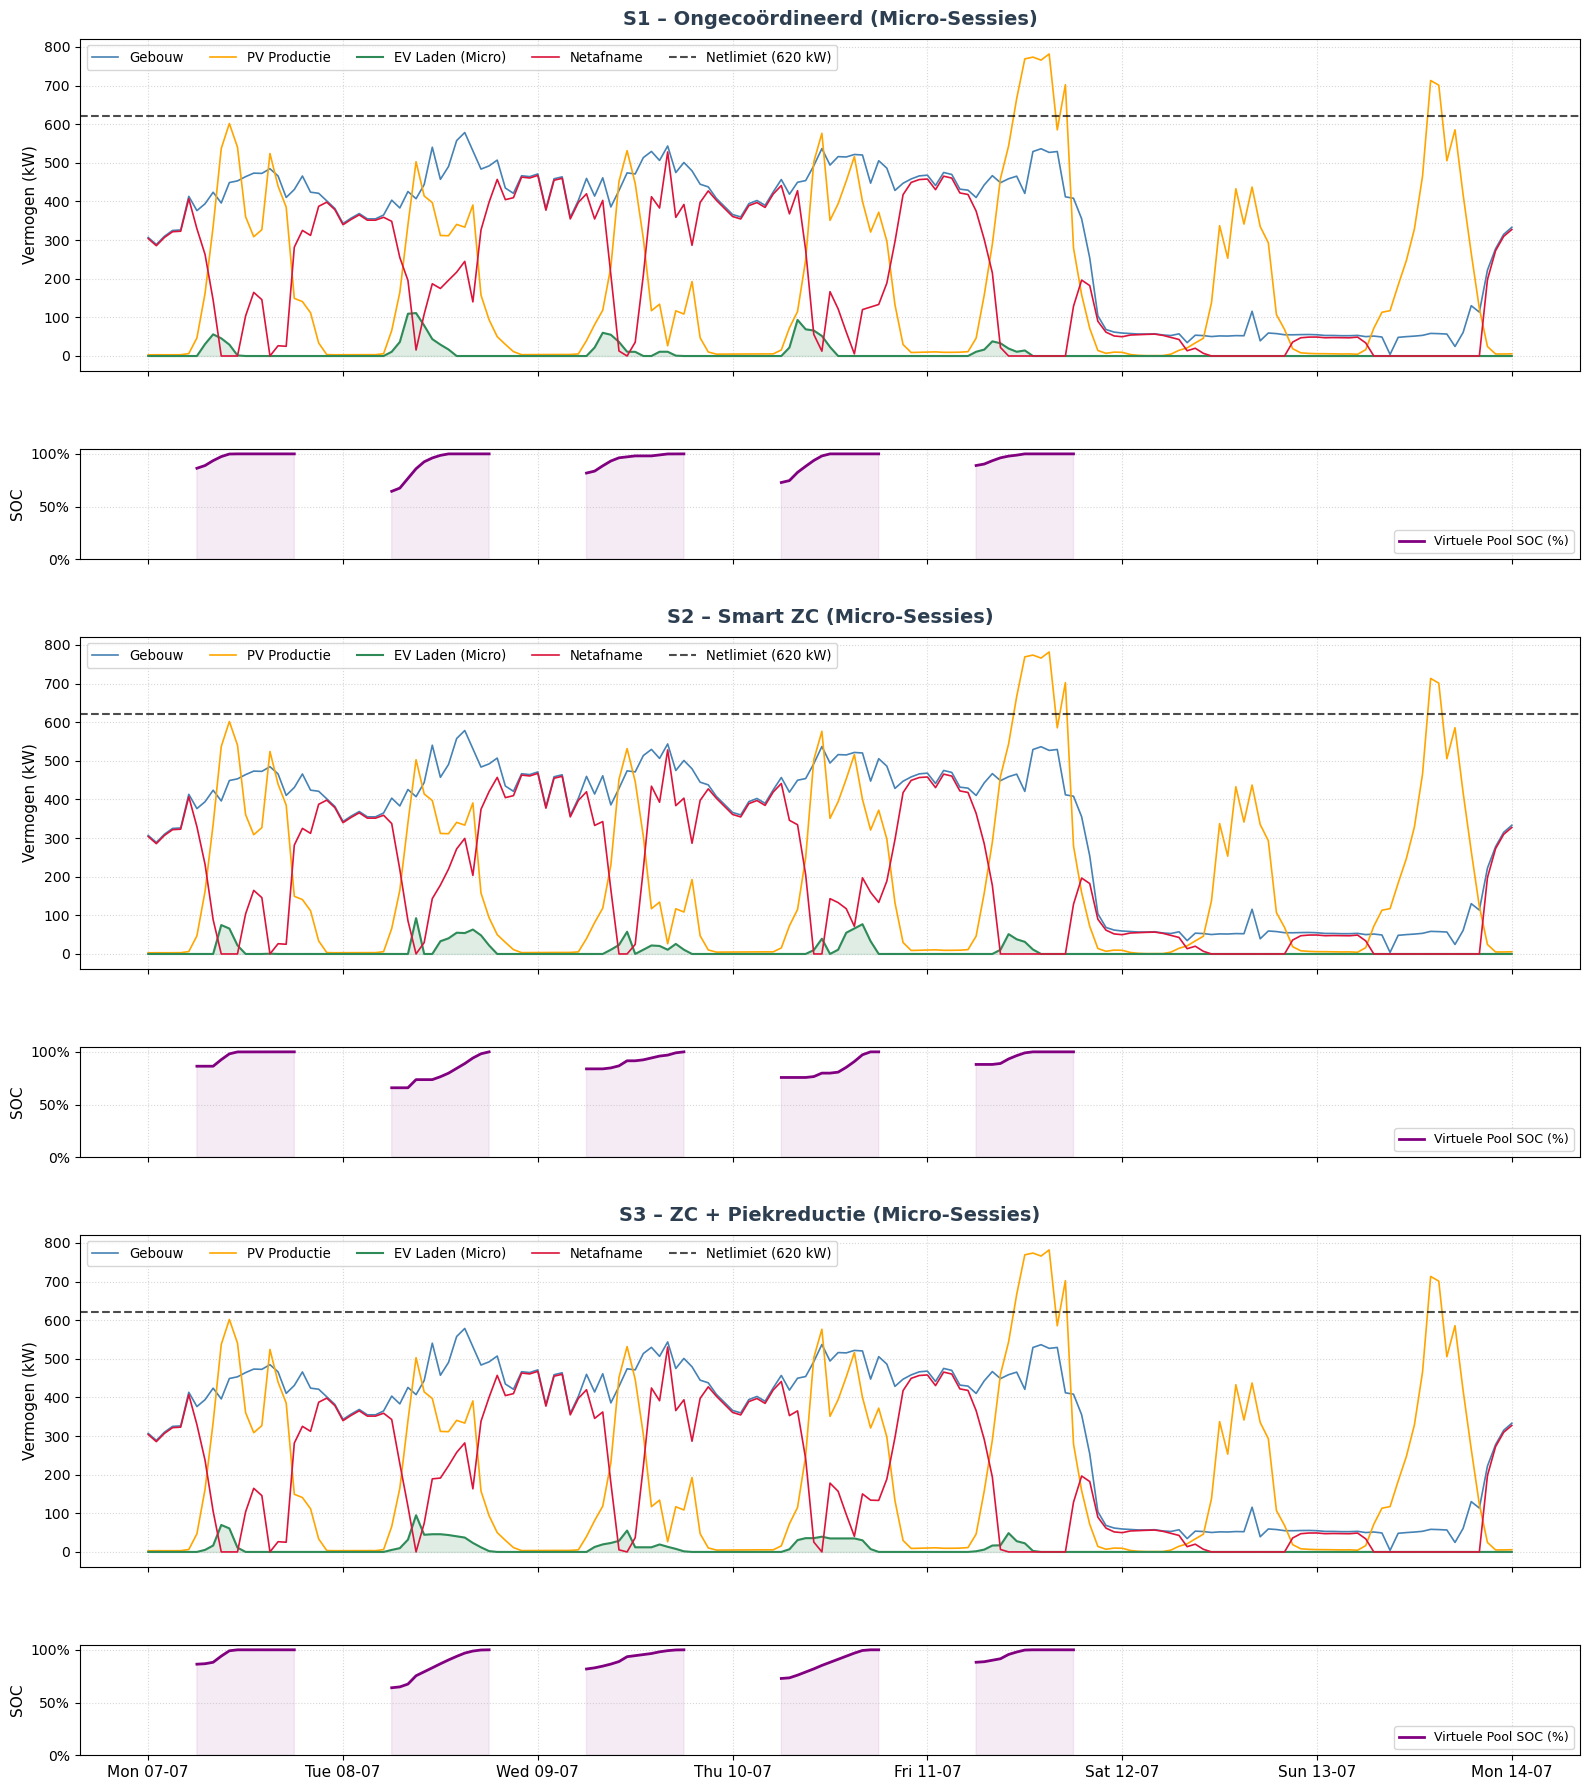

In [50]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np

# ============================================================
# INSTELLINGEN (Huidige situatie: 20 laadpunten)
# ============================================================
N_LAADPUNTEN_TOTAAL = 20
P_MAX_PUNT_KW = 11
TIJDSTAP_H = 1.0  
ACCU_KWH_PER_AUTO = 60  # Gemiddelde accugrootte voor de pool-schaal
P_NET_CAP = 620  # Jouw contract- of pieklimiet

# Selecteer een volledige week (7 dagen)
start_plot = pd.Timestamp('2025-07-07 00:00:00') # Start op een maandag voor een mooi weekoverzicht
eind_plot = start_plot + pd.Timedelta(days=7)
df_sim = df_main.loc[start_plot:eind_plot].copy()

# ============================================================
# VIRTUELE SOC BEREKENING OP MICRO-NIVEAU
# ============================================================
def bereken_virtuele_soc_micro(df_tijd, col_laad, n_punten):
    totale_pool_kwh = n_punten * ACCU_KWH_PER_AUTO
    soc_series = pd.Series(np.nan, index=df_tijd.index)
    
    # Filter de unieke werkdagen in deze week
    werkdagen = df_tijd.index[df_tijd.index.dayofweek < 5].normalize().unique()
    
    for dag in werkdagen:
        mask_dag = (df_tijd.index.normalize() == dag)
        # Breder aanwezigheidsvenster om alle micro-sessies op te vangen (6u tot 19u)
        mask_aanwezig = mask_dag & (df_tijd.index.hour >= 6) & (df_tijd.index.hour < 19)
        idx_aanwezig = df_tijd.index[mask_aanwezig]
        
        if len(idx_aanwezig) == 0:
            continue
            
        # De échte totale energie die deze specifieke micro-strategie VANDAAG heeft geladen
        e_geladen_vandaag = df_tijd.loc[mask_dag, col_laad].sum() * TIJDSTAP_H
        
        # Start-energie van de pool (totale capaciteit minus wat er vandaag nog geladen moet worden)
        start_energie = max(0.0, totale_pool_kwh - e_geladen_vandaag)
        huidige_energy = start_energie
        
        for t in idx_aanwezig:
            p_geladen = df_tijd.loc[t, col_laad]
            huidige_energy += (p_geladen * TIJDSTAP_H)
            huidige_energy = min(huidige_energy, totale_pool_kwh) 
            
            soc_series[t] = (huidige_energy / totale_pool_kwh) * 100
            
    return soc_series

# Koppeling aan de exacte micro-kolommen in jouw df_main
strategie_plot = {
    'S1 – Ongecoördineerd (Micro-Sessies)': ('P_laad_S1', 'P_net_S1'),
    'S2 – Smart ZC (Micro-Sessies)': ('P_laad_S2', 'P_net_S2'),
    'S3 – ZC + Piekreductie (Micro-Sessies)': ('P_laad_S3', 'P_net_S3'),
}

# ============================================================
# PLOTTEN (6 Subplots: 3x Power, 3x SOC)
# ============================================================
fig, axes = plt.subplots(6, 1, figsize=(16, 18), sharex=True, 
                         gridspec_kw={'height_ratios': [3, 1, 3, 1, 3, 1]})

ax_idx = 0
for naam, (col_laad, col_net) in strategie_plot.items():
    ax_power = axes[ax_idx]     
    ax_soc = axes[ax_idx + 1]   
    
    # Correcte kolomnamen uit jouw df_main toepassen
    gebouw = df_sim['verbruik_gebouw_kwh']
    pv = df_sim['productie_kwh']
    laad = df_sim[col_laad]
    net = df_sim[col_net]
    
    # Bereken de virtuele SOC op basis van de werkelijke micro-laaddata
    soc = bereken_virtuele_soc_micro(df_sim, col_laad, N_LAADPUNTEN_TOTAAL)

    # --- 1. POWER GRAFIEK (kW) ---
    ax_power.plot(df_sim.index, gebouw, color='steelblue', linewidth=1.2, label='Gebouw')
    ax_power.plot(df_sim.index, pv, color='orange', linewidth=1.2, label='PV Productie')
    ax_power.plot(df_sim.index, laad, color='seagreen', linewidth=1.5, label='EV Laden (Micro)')
    ax_power.plot(df_sim.index, net.clip(lower=0), color='crimson', linewidth=1.2, label='Netafname')
    ax_power.fill_between(df_sim.index, 0, laad, color='seagreen', alpha=0.15)
    
    # Voeg de harde contractlimiet/piek-cap toe ter referentie
    ax_power.axhline(P_NET_CAP, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Netlimiet ({P_NET_CAP} kW)')
    
    ax_power.set_title(naam, fontsize=14, fontweight='bold', pad=10, color='#2c3e50')
    ax_power.set_ylabel('Vermogen (kW)', fontsize=11)
    ax_power.grid(True, linestyle=':', alpha=0.5)
    ax_power.legend(loc='upper left', ncols=5, fontsize=9.5)

    # --- 2. SOC GRAFIEK (%) ---
    ax_soc.plot(df_sim.index, soc, color='purple', linewidth=2, label='Virtuele Pool SOC (%)')
    ax_soc.fill_between(df_sim.index, 0, soc, color='purple', alpha=0.08)
    
    ax_soc.set_ylabel('SOC', fontsize=11)
    ax_soc.set_ylim(0, 105) 
    ax_soc.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax_soc.grid(True, linestyle=':', alpha=0.5)
    ax_soc.legend(loc='lower right', fontsize=9)
    
    ax_idx += 2

# ============================================================
# X-AS OPMAAK (Tijd) - 7 Dagen Overzicht
# ============================================================
# Toon de dagnamen en datums op de X-as (bijv. Mon 05-05)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%a %d-%m'))
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.setp(axes[-1].get_xticklabels(), rotation=0, ha='center', fontsize=11)

plt.tight_layout()
plt.subplots_adjust(hspace=0.35) 
plt.show()

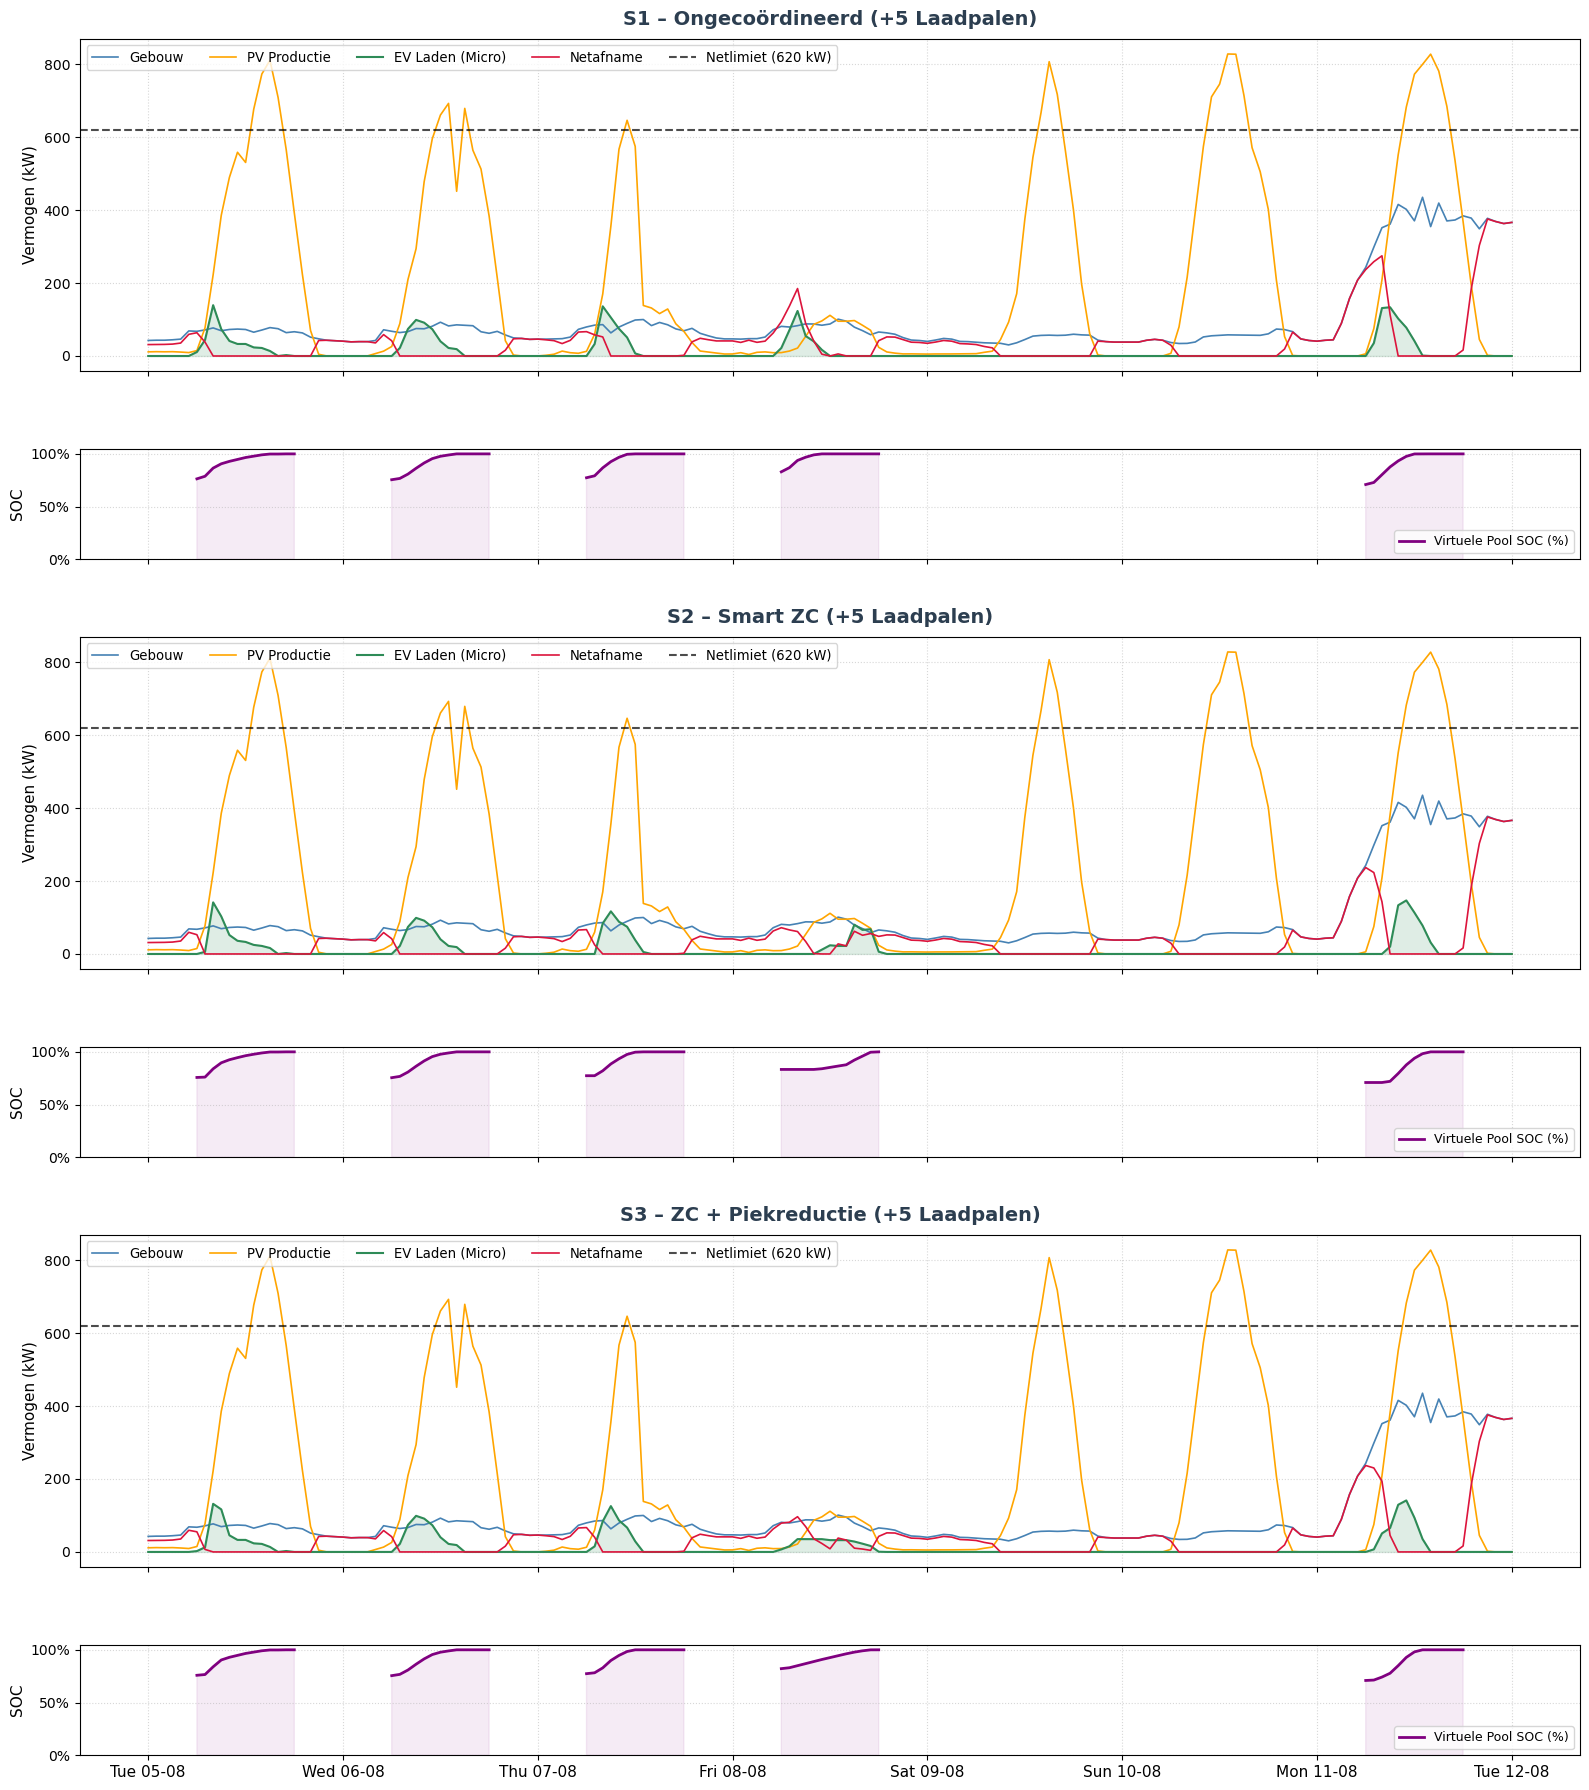

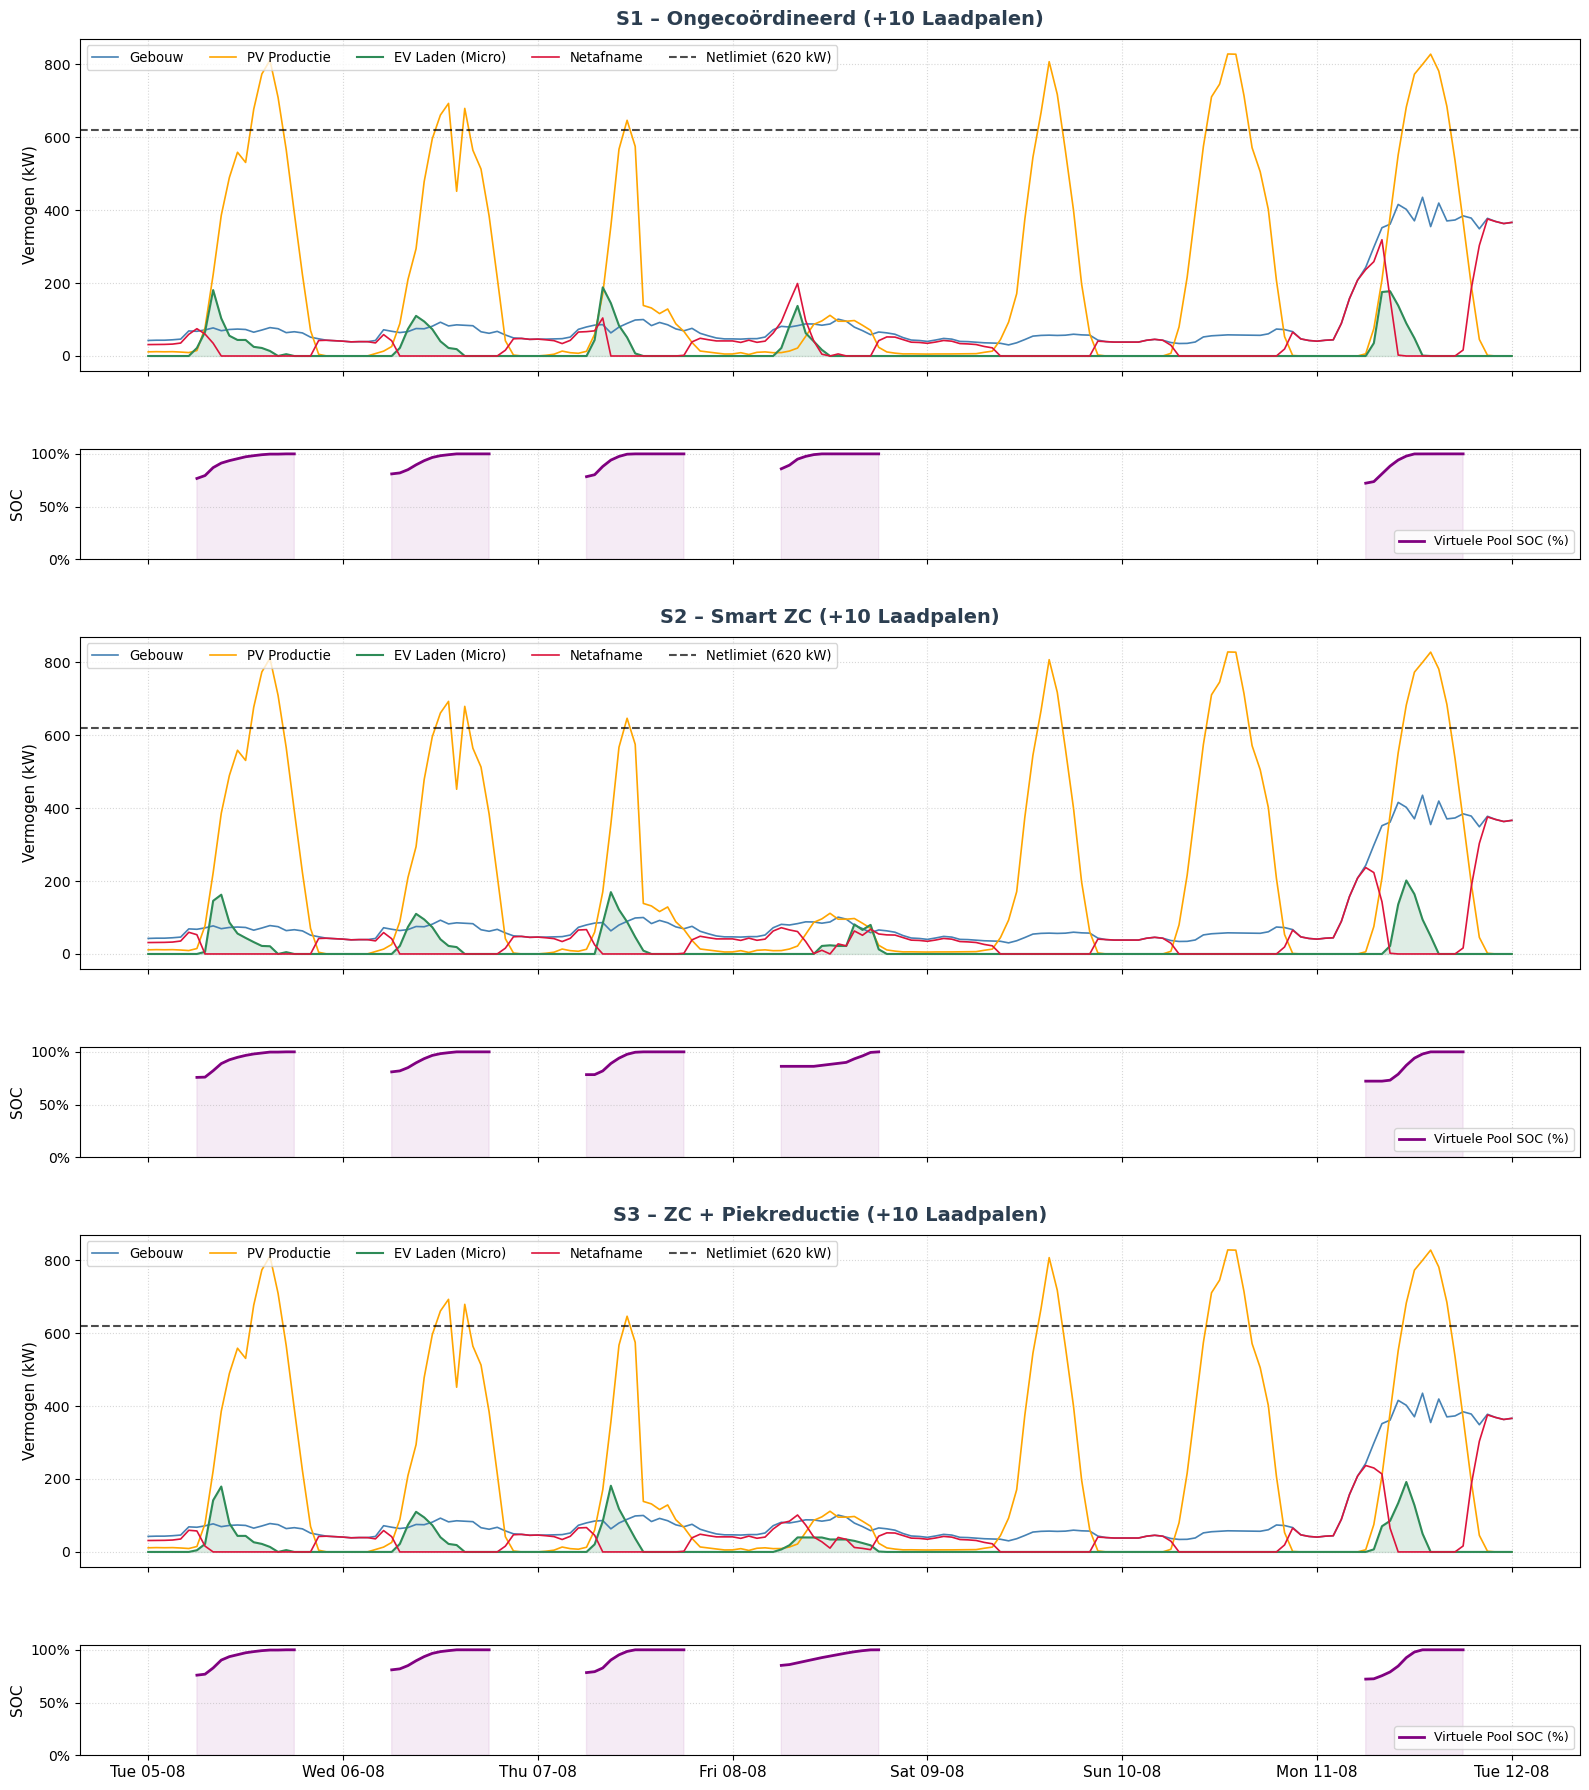

In [52]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np

# ============================================================
# ALGEMENE INSTELLINGEN
# ============================================================
TIJDSTAP_H = 1.0  
ACCU_KWH_PER_AUTO = 60  
P_NET_CAP = 620  # Jouw vaste contract/pieklimiet uit de laatste prompt

# Selecteer een volledige week (maandag tot zondag)
start_plot = pd.Timestamp('2025-08-05 00:00:00') 
eind_plot = start_plot + pd.Timedelta(days=7)
df_sim = df_main.loc[start_plot:eind_plot].copy()

# ============================================================
# VIRTUELE SOC BEREKENING (Aangepast voor scenario's)
# ============================================================
def bereken_virtuele_soc_micro(df_tijd, col_laad, n_punten):
    totale_pool_kwh = n_punten * ACCU_KWH_PER_AUTO
    soc_series = pd.Series(np.nan, index=df_tijd.index)
    
    werkdagen = df_tijd.index[df_tijd.index.dayofweek < 5].normalize().unique()
    
    for dag in werkdagen:
        mask_dag = (df_tijd.index.normalize() == dag)
        mask_aanwezig = mask_dag & (df_tijd.index.hour >= 6) & (df_tijd.index.hour < 19)
        idx_aanwezig = df_tijd.index[mask_aanwezig]
        
        if len(idx_aanwezig) == 0:
            continue
            
        e_geladen_vandaag = df_tijd.loc[mask_dag, col_laad].sum() * TIJDSTAP_H
        start_energie = max(0.0, totale_pool_kwh - e_geladen_vandaag)
        huidige_energy = start_energie
        
        for t in idx_aanwezig:
            p_geladen = df_tijd.loc[t, col_laad]
            huidige_energy += (p_geladen * TIJDSTAP_H)
            huidige_energy = min(huidige_energy, totale_pool_kwh) 
            
            soc_series[t] = (huidige_energy / totale_pool_kwh) * 100
            
    return soc_series

# ============================================================
# CENTRAL PLOTTING FUNCTION FOR SCENARIOS
# ============================================================
def maak_scenario_grafiek(df_tijd, titel_hoofd, suffix, n_laadpunten):
    # Dynamisch de kolommen mappen op basis van de suffix (_plus10p of _plus20p)
    strategie_plot = {
        f'S1 – Ongecoördineerd ({titel_hoofd})': (f'P_laad_S1_{suffix}', f'P_net_S1_{suffix}'),
        f'S2 – Smart ZC ({titel_hoofd})': (f'P_laad_S2_{suffix}', f'P_net_S2_{suffix}'),
        f'S3 – ZC + Piekreductie ({titel_hoofd})': (f'P_laad_S3_{suffix}', f'P_net_S3_{suffix}'),
    }

    fig, axes = plt.subplots(6, 1, figsize=(16, 18), sharex=True, 
                             gridspec_kw={'height_ratios': [3, 1, 3, 1, 3, 1]})

    ax_idx = 0
    for naam, (col_laad, col_net) in strategie_plot.items():
        ax_power = axes[ax_idx]     
        ax_soc = axes[ax_idx + 1]   
        
        gebouw = df_tijd['verbruik_gebouw_kwh']
        pv = df_tijd['productie_kwh']
        laad = df_tijd[col_laad]
        net = df_tijd[col_net]
        
        # Bereken de SOC specifiek voor de grotere batterijpool
        soc = bereken_virtuele_soc_micro(df_tijd, col_laad, n_laadpunten)

        # --- 1. POWER GRAFIEK (kW) ---
        ax_power.plot(df_tijd.index, gebouw, color='steelblue', linewidth=1.2, label='Gebouw')
        ax_power.plot(df_tijd.index, pv, color='orange', linewidth=1.2, label='PV Productie')
        ax_power.plot(df_tijd.index, laad, color='seagreen', linewidth=1.5, label='EV Laden (Micro)')
        ax_power.plot(df_tijd.index, net.clip(lower=0), color='crimson', linewidth=1.2, label='Netafname')
        ax_power.fill_between(df_tijd.index, 0, laad, color='seagreen', alpha=0.15)
        
        # Voeg de harde netlimiet (620 kW) toe
        ax_power.axhline(P_NET_CAP, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Netlimiet ({P_NET_CAP} kW)')
        
        ax_power.set_title(naam, fontsize=14, fontweight='bold', pad=10, color='#2c3e50')
        ax_power.set_ylabel('Vermogen (kW)', fontsize=11)
        ax_power.grid(True, linestyle=':', alpha=0.5)
        ax_power.legend(loc='upper left', ncols=5, fontsize=9.5)

        # --- 2. SOC GRAFIEK (%) ---
        ax_soc.plot(df_tijd.index, soc, color='purple', linewidth=2, label='Virtuele Pool SOC (%)')
        ax_soc.fill_between(df_tijd.index, 0, soc, color='purple', alpha=0.08)
        
        ax_soc.set_ylabel('SOC', fontsize=11)
        ax_soc.set_ylim(0, 105) 
        ax_soc.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax_soc.grid(True, linestyle=':', alpha=0.5)
        ax_soc.legend(loc='lower right', fontsize=9)
        
        ax_idx += 2

    # X-as opmaak voor de onderste subplot
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%a %d-%m'))
    axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=1))
    plt.setp(axes[-1].get_xticklabels(), rotation=0, ha='center', fontsize=11)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.35) 
    plt.show()

# ============================================================
# GENEREER DE GRAFIEKEN VOOR DE TWEE SCENARIO'S
# ============================================================

# Grafiek 1: +5 Laadpalen (Totaal 30 laadpunten, suffix '_plus10p')
maak_scenario_grafiek(df_sim, "+5 Laadpalen", "plus10p", n_laadpunten=30)

# Grafiek 2: +10 Laadpalen (Totaal 40 laadpunten, suffix '_plus20p')
maak_scenario_grafiek(df_sim, "+10 Laadpalen", "plus20p", n_laadpunten=40)

Simulatie gestart (0 tot 40 laadpalen). Dit kan ongeveer een minuut duren...
Micro-simulatie S2 (Smart ZC) wordt uitgevoerd met 2 laadpunten...
Micro-simulatie S2 (Smart ZC) wordt uitgevoerd met 4 laadpunten...
Micro-simulatie S2 (Smart ZC) wordt uitgevoerd met 6 laadpunten...
Micro-simulatie S2 (Smart ZC) wordt uitgevoerd met 8 laadpunten...
Micro-simulatie S2 (Smart ZC) wordt uitgevoerd met 10 laadpunten...
Micro-simulatie S2 (Smart ZC) wordt uitgevoerd met 12 laadpunten...
Micro-simulatie S2 (Smart ZC) wordt uitgevoerd met 14 laadpunten...
Micro-simulatie S2 (Smart ZC) wordt uitgevoerd met 16 laadpunten...
Micro-simulatie S2 (Smart ZC) wordt uitgevoerd met 18 laadpunten...
Micro-simulatie S2 (Smart ZC) wordt uitgevoerd met 20 laadpunten...
Micro-simulatie S2 (Smart ZC) wordt uitgevoerd met 22 laadpunten...
Micro-simulatie S2 (Smart ZC) wordt uitgevoerd met 24 laadpunten...
Micro-simulatie S2 (Smart ZC) wordt uitgevoerd met 26 laadpunten...
Micro-simulatie S2 (Smart ZC) wordt uitgevo

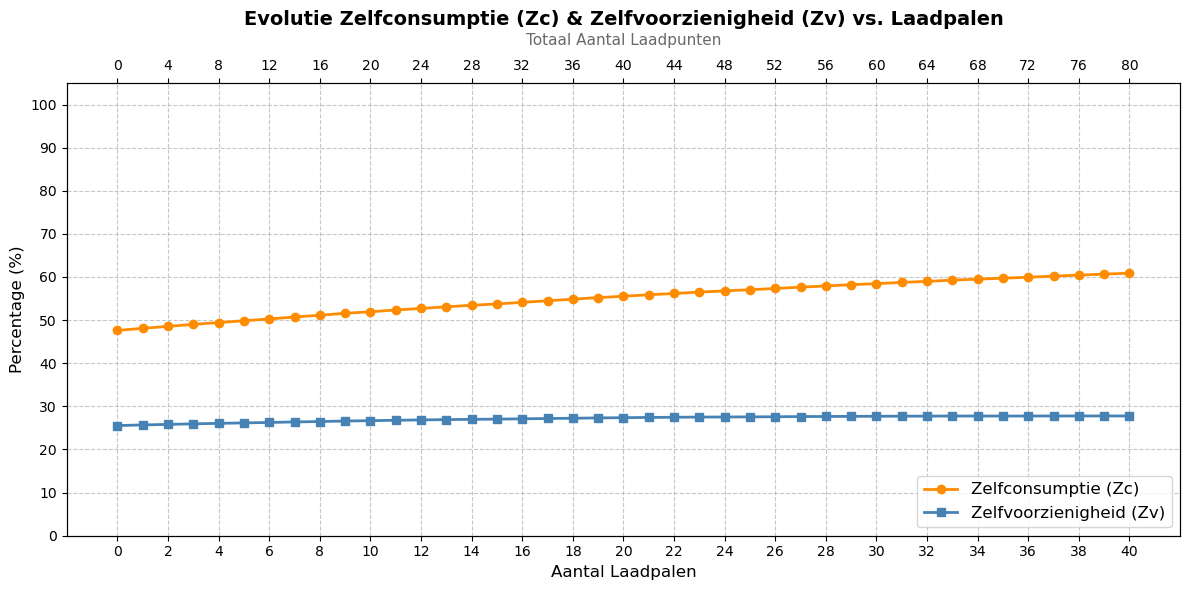

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. INSTELLINGEN
# ==========================================
MAX_LAADPALEN = 40
LAADPUNTEN_PER_PAAL = 2
TIJDSTAP_H = 1.0

# Kies hier welke strategie je in de grafiek wilt zien:
gekozen_strategie = strategie_2_smart_zc_micro 

# Lijsten om de uitkomsten in te verzamelen
palen_reeks = list(range(0, MAX_LAADPALEN + 1)) 
zc_reeks = []
zv_reeks = []

print("Simulatie gestart (0 tot 40 laadpalen). Dit kan ongeveer een minuut duren...")

# ==========================================
# 2. ITEREREN & SIMULEREN
# ==========================================
for palen in palen_reeks:
    punten = palen * LAADPUNTEN_PER_PAAL
    
    # Voortgang printen
    print(f"Bezig met simuleren: {palen} laadpalen ({punten} punten)...", end='\r')
    
    if palen == 0:
        # Geen EV: Laadvermogen is 0
        P_laad = pd.Series(0.0, index=df_main.index)
    else:
        # Bepaal opschalingsfactor t.o.v. de basissituatie (20 punten)
        factor = punten / 20.0
        
        # Veilig downscalen of upscalen
        if factor < 1.0:
            df_sessies_scaled = df_laad_clean.sample(frac=factor, random_state=42).copy()
        else:
            df_sessies_scaled = genereer_extra_sessies(df_laad_clean, factor)
            
        # Voer de simulatie uit voor dit aantal laadpunten
        P_laad = gekozen_strategie(
            df_hoofd=df_main, 
            df_sessies=df_sessies_scaled, 
            n_laadpunten=punten, 
            p_max_punt=11.0, 
            tijdstap_h=TIJDSTAP_H
        )

    # ==========================================
    # 3. KPI'S BEREKENEN
    # ==========================================
    P_net = df_main['verbruik_gebouw_kwh'] + P_laad - df_main['productie_kwh']
    
    P_pv = df_main['productie_kwh']
    P_gebouw = df_main['verbruik_gebouw_kwh']

    E_verbruik = ((P_gebouw + P_laad) * TIJDSTAP_H).sum()
    E_opbrengst = (P_pv * TIJDSTAP_H).sum()

    E_aangekocht = (P_net.clip(lower=0) * TIJDSTAP_H).sum()
    E_geinjecteerd = ((-P_net).clip(lower=0) * TIJDSTAP_H).sum()

    # Zelfconsumptie: welk deel van de zonnestroom is lokaal verbruikt?
    zc_pct = 100 * (E_opbrengst - E_geinjecteerd) / E_opbrengst if E_opbrengst > 0 else 0
    # Zelfvoorzienigheid: welk deel van het totaal verbruik komt uit zonnestroom?
    zv_pct = 100 * (E_verbruik - E_aangekocht) / E_verbruik if E_verbruik > 0 else 0
    
    zc_reeks.append(zc_pct)
    zv_reeks.append(zv_pct)

print("\nSimulatie voltooid! Grafiek wordt gegenereerd...")

# ==========================================
# 4. GRAFIEK GENEREREN
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot lijnen
ax1.plot(palen_reeks, zc_reeks, marker='o', linestyle='-', color='darkorange', linewidth=2, label='Zelfconsumptie (Zc)')
ax1.plot(palen_reeks, zv_reeks, marker='s', linestyle='-', color='steelblue', linewidth=2, label='Zelfvoorzienigheid (Zv)')

# Vormgeving
ax1.set_title("Evolutie Zelfconsumptie (Zc) & Zelfvoorzienigheid (Zv) vs. Laadpalen", fontsize=14, fontweight='bold')
ax1.set_xlabel("Aantal Laadpalen", fontsize=12)
ax1.set_ylabel("Percentage (%)", fontsize=12)

# As instellingen
ax1.set_xticks(np.arange(0, MAX_LAADPALEN + 1, step=2))
ax1.set_yticks(np.arange(0, 101, step=10))
ax1.set_ylim(0, 105)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='lower right', fontsize=12)

# Extra X-as (bovenaan) voor de laadpunten ter verduidelijking
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(ax1.get_xticks())
ax2.set_xticklabels([int(x * LAADPUNTEN_PER_PAAL) for x in ax1.get_xticks()])
ax2.set_xlabel("Totaal Aantal Laadpunten", fontsize=11, color='dimgray', labelpad=10)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. INSTELLINGEN
# ==========================================
MAX_LAADPALEN = 40
LAADPUNTEN_PER_PAAL = 2
TIJDSTAP_H = 1.0

# Zet hier jouw 3 strategie-functies in een dictionary met een mooie naam voor de grafiek
strategieen = {
    "Strat 1: Dom Laden": strategie_1_ongecoordineerd_micro,
    "Strat 2: Smart ZC": strategie_2_smart_zc_micro,
    "Strat 3: Smart Prijs": strategie_3_smart_zc_piek_micro
}

palen_reeks = list(range(0, MAX_LAADPALEN + 1)) 

# Dictionaries om de Zc en Zv reeksen per strategie in op te slaan
resultaten_zc = {naam: [] for naam in strategieen}
resultaten_zv = {naam: [] for naam in strategieen}

print("Simulatie gestart voor meerdere strategieën. Dit duurt even...")

# ==========================================
# 2. ITEREREN & SIMULEREN
# ==========================================
for naam_strategie, functie_strategie in strategieen.items():
    print(f"\n--- Bezig met berekenen van: {naam_strategie} ---")
    
    for palen in palen_reeks:
        punten = palen * LAADPUNTEN_PER_PAAL
        
        print(f"Laadpalen: {palen} ({punten} punten)...", end='\r')
        
        if palen == 0:
            P_laad = pd.Series(0.0, index=df_main.index)
        else:
            factor = punten / 20.0
            
            if factor < 1.0:
                df_sessies_scaled = df_laad_clean.sample(frac=factor, random_state=42).copy()
            else:
                df_sessies_scaled = genereer_extra_sessies(df_laad_clean, factor)
                
            # Voer de simulatie uit met de HUIDIGE strategie in de loop
            P_laad = functie_strategie(
                df_hoofd=df_main, 
                df_sessies=df_sessies_scaled, 
                n_laadpunten=punten, 
                p_max_punt=11.0, 
                tijdstap_h=TIJDSTAP_H
            )

        # ==========================================
        # 3. KPI'S BEREKENEN
        # ==========================================
        P_net = df_main['verbruik_gebouw_kwh'] + P_laad - df_main['productie_kwh']
        P_pv = df_main['productie_kwh']
        P_gebouw = df_main['verbruik_gebouw_kwh']

        E_verbruik = ((P_gebouw + P_laad) * TIJDSTAP_H).sum()
        E_opbrengst = (P_pv * TIJDSTAP_H).sum()
        E_aangekocht = (P_net.clip(lower=0) * TIJDSTAP_H).sum()
        E_geinjecteerd = ((-P_net).clip(lower=0) * TIJDSTAP_H).sum()

        zc_pct = 100 * (E_opbrengst - E_geinjecteerd) / E_opbrengst if E_opbrengst > 0 else 0
        zv_pct = 100 * (E_verbruik - E_aangekocht) / E_verbruik if E_verbruik > 0 else 0
        
        # Sla het resultaat op in het juiste lijstje van deze strategie
        resultaten_zc[naam_strategie].append(zc_pct)
        resultaten_zv[naam_strategie].append(zv_pct)

print("\n\nSimulaties voltooid! Grafiek wordt gegenereerd...")

# ==========================================
# 4. GRAFIEK GENEREREN
# ==========================================
fig, ax1 = plt.subplots(figsize=(14, 7))

# Kleuren bepalen zodat de grafiek overzichtelijk blijft
kleuren = ["firebrick", "seagreen", "royalblue"]

# We plotten nu alle bewaarde lijnen uit onze resultaten-dictionaries
for (naam_strategie, zc_lijst), kleur in zip(resultaten_zc.items(), kleuren):
    # Zelfconsumptie: volle lijn met een bolletje
    ax1.plot(palen_reeks, zc_lijst, marker='o', linestyle='-', color=kleur, linewidth=2, label=f'Zc - {naam_strategie}')
    
    # Zelfvoorziening: stippellijn met een vierkantje
    zv_lijst = resultaten_zv[naam_strategie]
    ax1.plot(palen_reeks, zv_lijst, marker='s', linestyle='--', color=kleur, linewidth=2, alpha=0.8, label=f'Zv - {naam_strategie}')

# Vormgeving
ax1.set_title("Vergelijking Zc & Zv per Laadstrategie", fontsize=15, fontweight='bold')
ax1.set_xlabel("Aantal Laadpalen", fontsize=12)
ax1.set_ylabel("Percentage (%)", fontsize=12)

# As instellingen
ax1.set_xticks(np.arange(0, MAX_LAADPALEN + 1, step=2))
ax1.set_yticks(np.arange(0, 101, step=10))
ax1.set_ylim(0, 105)
ax1.grid(True, linestyle=':', alpha=0.7)

# Legende buiten de grafiek plaatsen om overlap met lijnen te voorkomen
ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10, borderaxespad=0.)

# Extra X-as (bovenaan) voor de laadpunten
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(ax1.get_xticks())
ax2.set_xticklabels([int(x * LAADPUNTEN_PER_PAAL) for x in ax1.get_xticks()])
ax2.set_xlabel("Totaal Aantal Laadpunten", fontsize=11, color='dimgray', labelpad=10)

plt.tight_layout()
plt.show()